In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../artifacts/raw_data/retail_store_inventory.csv")

In [3]:
df = pd.DataFrame(data)

In [4]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


# Basic Dataset Overview

In [5]:
df.shape

(76000, 16)

In [6]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("\nNumerical Columns:")
print(numerical_columns)

print("Number of numerical columns:", len(numerical_columns))


Numerical Columns:
['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic', 'Demand']
Number of numerical columns: 9


In [7]:
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)

print("Number of categorical columns:", len(categorical_columns))


Categorical Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']
Number of categorical columns: 7


In [8]:
target = "Demand"

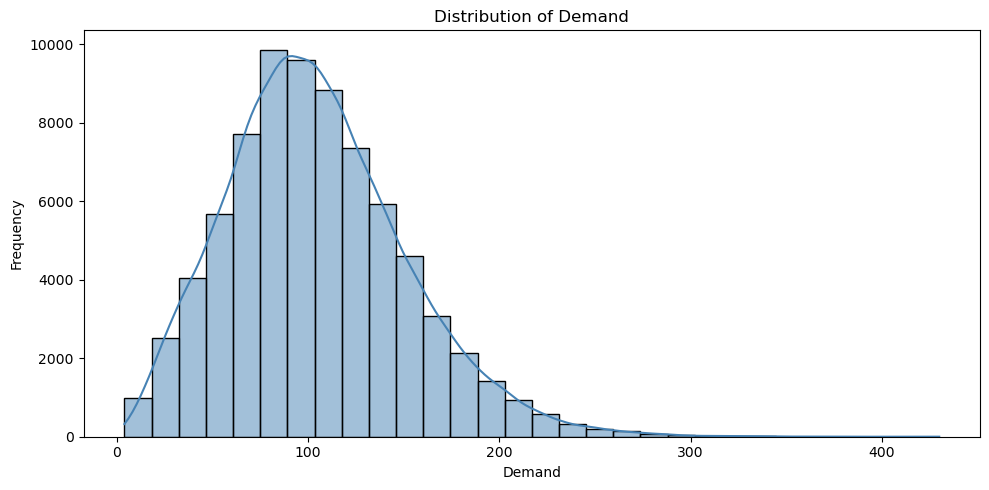

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x=target,
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insights:
- Most products have moderate demand, roughly around **70–130 units**.
- A smaller number of observations have very high demand, creating a **right-skewed distribution**.
- The majority of demand values are concentrated around **80–120 units**.

In [10]:
df[target].isnull().sum()

np.int64(0)

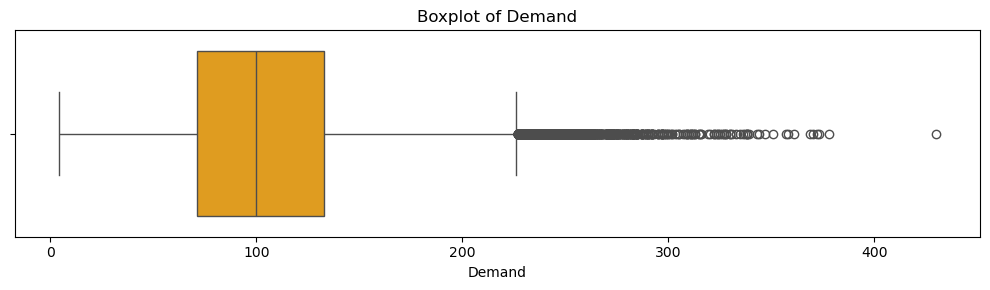

In [11]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df,
    x=target,
    color="orange"
)

plt.title("Boxplot of Demand")
plt.xlabel("Demand")
plt.tight_layout()
plt.show()

### Insights

#### The boxplot shows that demand is right-skewed, with the majority of observations concentrated roughly between **71 and 133 units**. Several high-demand observations extend beyond the upper whisker, reaching up to **430 units**. These observations should be investigated further rather than removed automatically, as they may represent genuine high-demand business scenarios such as promotions, discounts, or seasonal effects.

# Univariate Analysis

In [12]:
numerical_columns

['Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Price',
 'Discount',
 'Promotion',
 'Competitor Pricing',
 'Epidemic',
 'Demand']

In [13]:
# Inventory Level
df['Inventory Level'].dtype

dtype('int64')

In [14]:
df['Inventory Level'].nunique()

1426

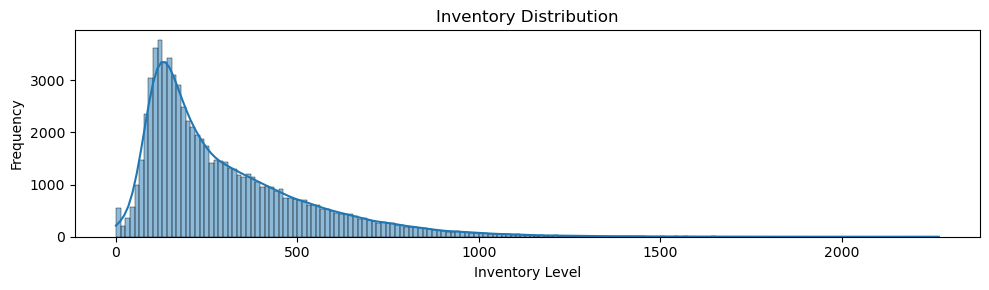

In [15]:
# Histogram
plt.figure(figsize=(10, 3))

sns.histplot(
    data=df,
    x="Inventory Level",
    kde=True
)

plt.title("Inventory Distribution")
plt.xlabel("Inventory Level")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Insights

#### The inventory distribution is strongly right-skewed, with most observations concentrated at relatively low to moderate inventory levels. A smaller number of observations have very high inventory levels, extending to around **2,267 units**, indicating substantial variability and potential outliers that should be investigated further.


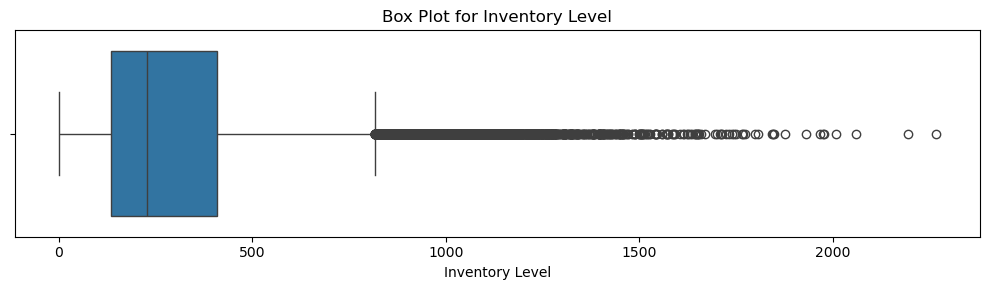

In [16]:
# Boxplot
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df,
    x="Inventory Level",
)

plt.title("Box Plot for Inventory Level")
plt.xlabel("Inventory Level")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Insights

#### The boxplot confirms that inventory level is strongly right-skewed. The majority of observations fall within a moderate range, while numerous potential outliers occur at higher inventory levels, with some values exceeding **2,000 units**. These extreme observations should be investigated further rather than removed automatically.

In [17]:
# Central Tendency
df["Inventory Level"].mean()

np.float64(301.06284210526314)

In [18]:
df["Inventory Level"].median()

227.0

### Insights

#### The average inventory level is approximately **301 units**, while the median is **227 units**. Since the mean is noticeably higher than the median, this indicates that the inventory distribution is **right-skewed**, with higher inventory values pulling the average upward.

In [19]:
# Spread
df["Inventory Level"].describe()

count    76000.000000
mean       301.062842
std        226.510161
min          0.000000
25%        136.000000
50%        227.000000
75%        408.000000
max       2267.000000
Name: Inventory Level, dtype: float64

In [20]:
skewness = df["Inventory Level"].skew()

print("Skewness:", skewness)

Skewness: 1.5919384125349623


In [21]:
skewness = df["Inventory Level"].skew()

if skewness < -0.5:
    print("Negatively / left-skewed")
elif skewness > 0.5:
    print("Positively / right-skewed")
else:
    print("Approximately symmetric")

Positively / right-skewed


In [22]:
numerical_columns

['Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Price',
 'Discount',
 'Promotion',
 'Competitor Pricing',
 'Epidemic',
 'Demand']

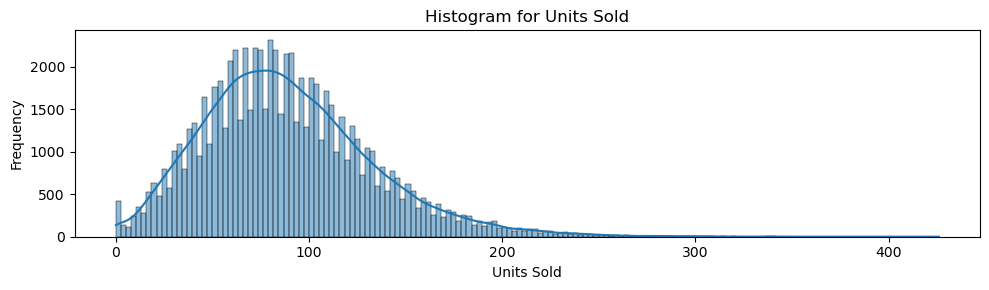

In [23]:
# Units Sold

# Histogram
plt.figure(figsize=(10,3))

sns.histplot(
    data = df,
    x = "Units Sold",
    kde = True,
)

plt.title("Histogram for Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.tight_layout()

### Insights

#### The distribution of units sold is **right-skewed**, with most observations concentrated around **50–120 units**. A smaller number of observations have substantially higher sales, extending to around **430 units**, indicating potential high-sales outliers that should be investigated further.

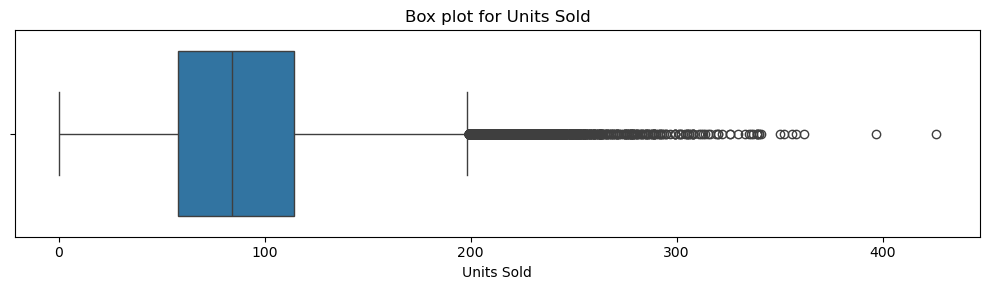

In [24]:
# Boxplot

plt.figure(figsize=(10,3))

sns.boxplot(
    data = df,
    x = "Units Sold"
)

plt.title("Box plot for Units Sold")
plt.xlabel("Units Sold")
plt.tight_layout()

### Insights

#### The boxplot shows that units sold is **right-skewed**, with the middle 50% of observations concentrated roughly between **50 and 115 units**. Several potential high-sales outliers occur above **200 units**, with a few extreme values reaching around **430 units**. These observations should be investigated further rather than removed automatically.

In [25]:
df["Units Sold"].describe()

count    76000.000000
mean        88.827316
std         43.994525
min          0.000000
25%         58.000000
50%         84.000000
75%        114.000000
max        426.000000
Name: Units Sold, dtype: float64

In [26]:
skewness = df["Units Sold"].skew()
print("Skewness: ",skewness)

Skewness:  0.7904285195202494


In [27]:
if skewness < -0.5:
    print("Negatively / Left Skewed")
elif skewness > 0.5:
    print("Positively / Right Skewed")
else:
    print("Approximately Symmetric")

Positively / Right Skewed


In [28]:
numerical_columns

['Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Price',
 'Discount',
 'Promotion',
 'Competitor Pricing',
 'Epidemic',
 'Demand']

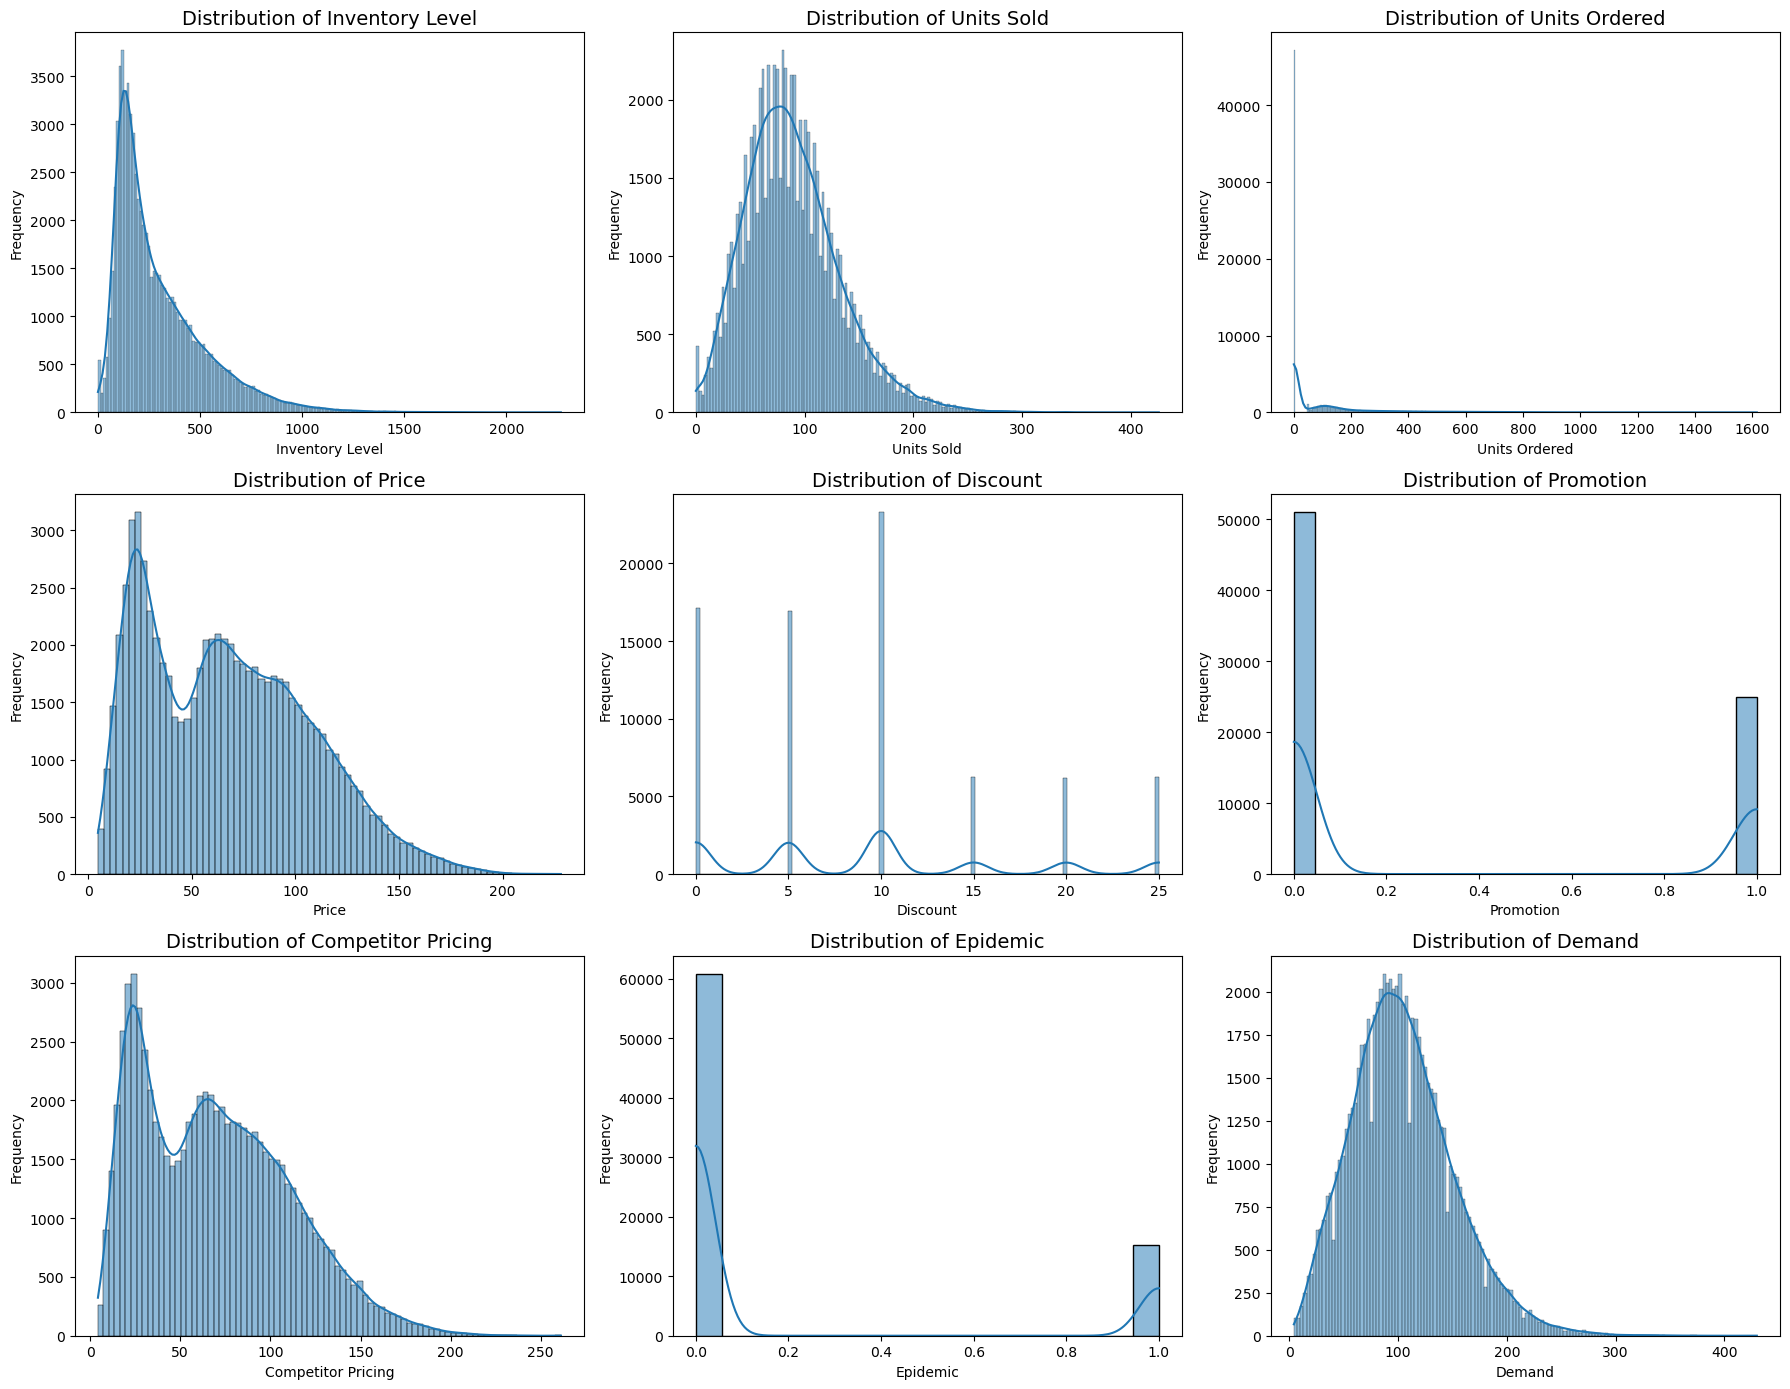

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}", fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide unused subplot
for i in range(len(numerical_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()

### Insights

#### The numerical features show different distribution patterns across the dataset. **Inventory Level, Units Sold, Units Ordered, and Demand** are generally right-skewed, with long upper tails and potential high-value observations. **Price and Competitor Pricing** show multiple concentration ranges rather than a simple symmetric distribution. **Discount** takes a limited set of discrete values, while **Promotion and Epidemic** are binary variables. These distribution patterns should be considered during further EDA and feature engineering.

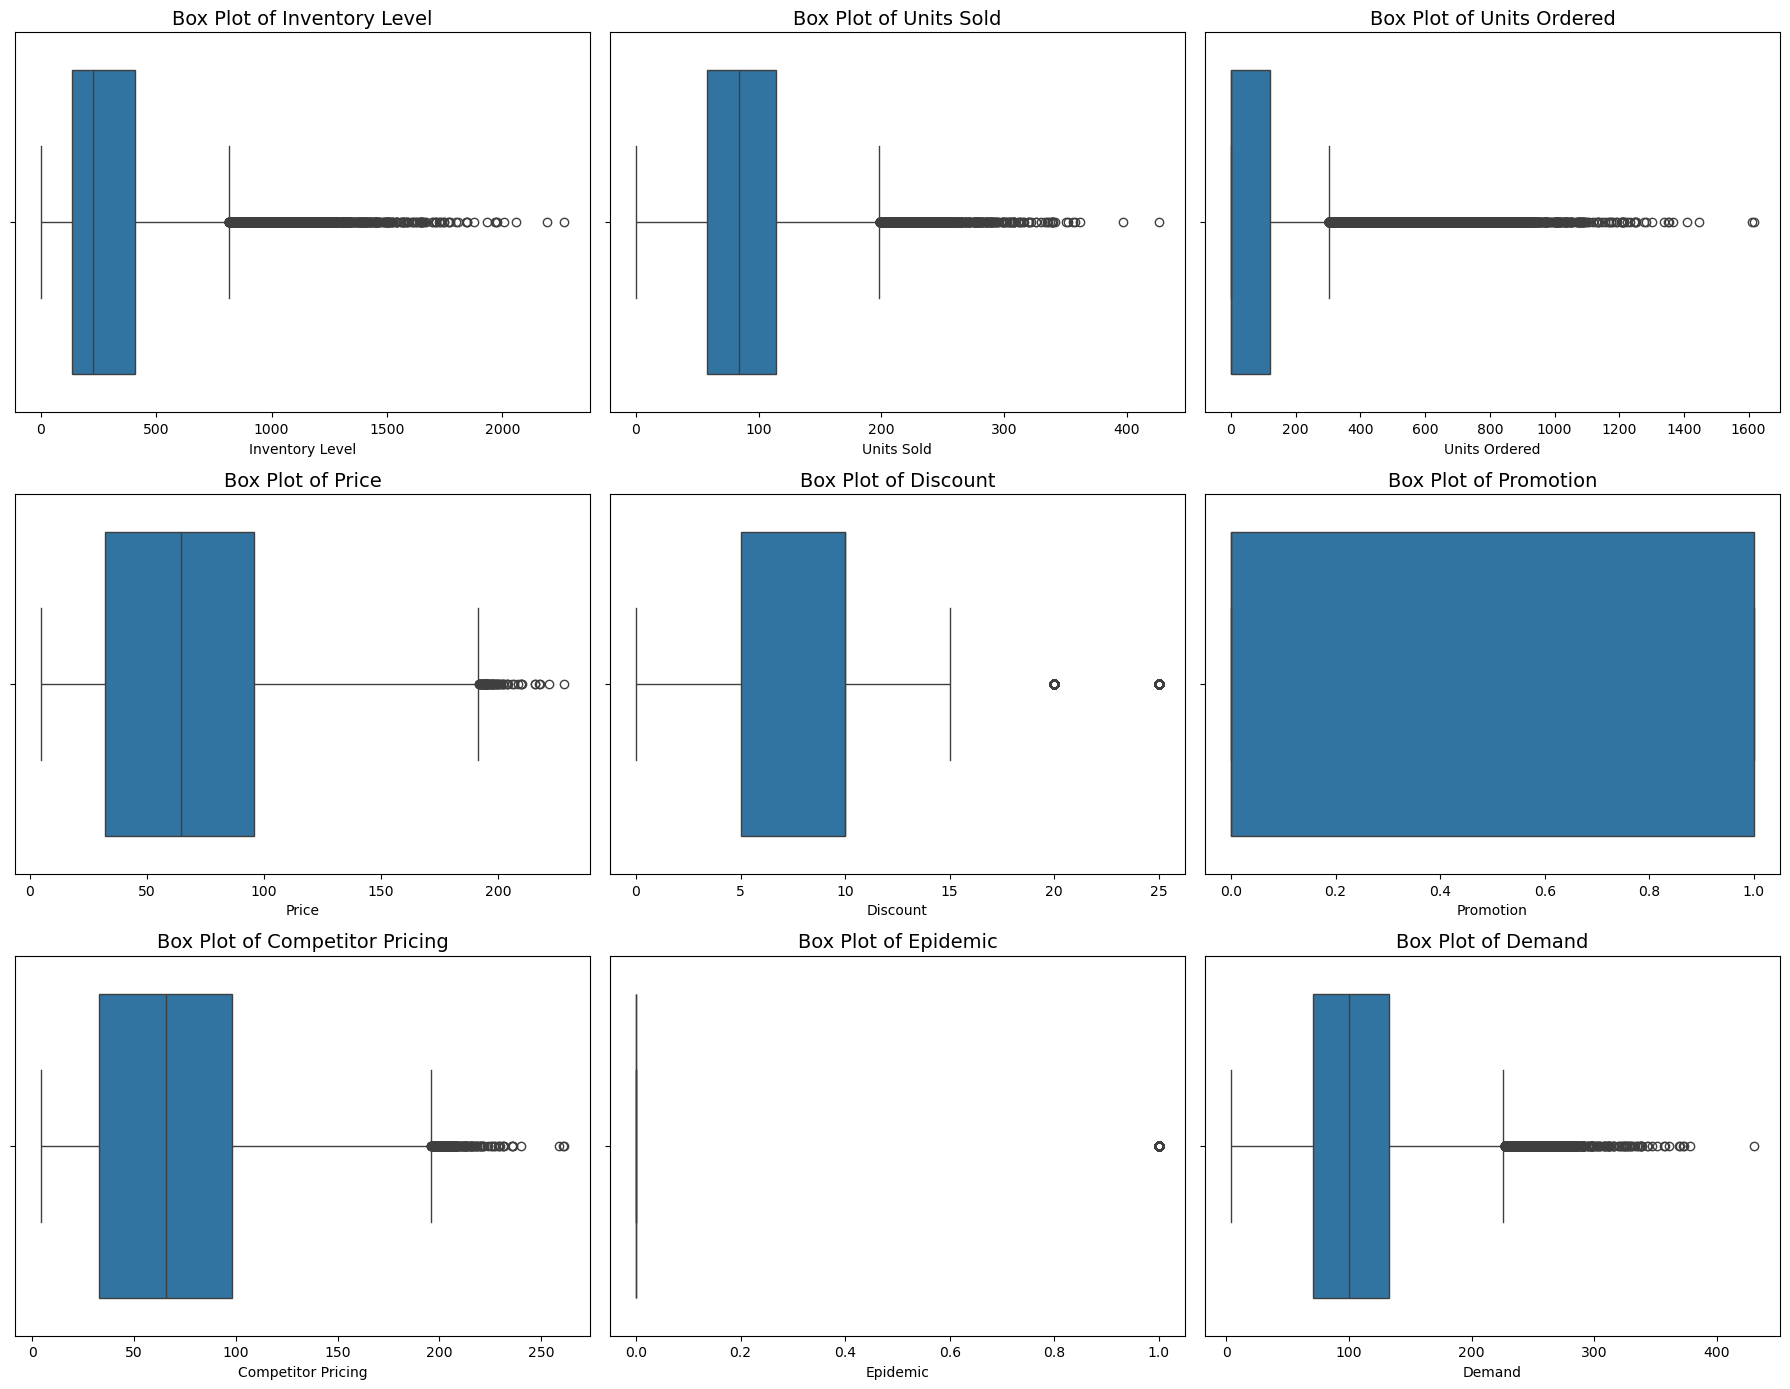

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Box Plot of {col}", fontsize=14)
    axes[i].set_xlabel(col)

# Hide unused subplot
for i in range(len(numerical_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()

### Insights

#### The boxplots show that **Inventory Level, Units Sold, Units Ordered, Price, Competitor Pricing, and Demand** contain several potential high-value outliers and generally exhibit right-skewed distributions. **Units Ordered** shows particularly extreme values, while **Demand and Units Sold** contain numerous high-value observations beyond their upper whiskers. The outliers should be investigated further rather than removed automatically. **Discount** contains discrete values rather than continuous observations, while **Promotion and Epidemic** are binary variables and are better analyzed using categorical visualizations.

In [31]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [32]:
# Skewness
for col in numerical_columns:
    skewness = df[col].skew()

    if skewness < -0.5:
        print(f"Skewness: {skewness}")
        print(f"{col} is: Negatively / Left Skewed")
    elif skewness > 0.5:
        print(f"Skewness: {skewness}")
        print(f"{col} is: Positively / Right Skewed")
    else:
        print(f"Skewness: {skewness}")
        print(f"{col} is: Approximately Symmetric")
    
    # print(f"{col} is ")

Skewness: 1.5919384125349623
Inventory Level is: Positively / Right Skewed
Skewness: 0.7904285195202494
Units Sold is: Positively / Right Skewed
Skewness: 2.515877842227715
Units Ordered is: Positively / Right Skewed
Skewness: 0.48502495845793697
Price is: Approximately Symmetric
Skewness: 0.6431486546403932
Discount is: Positively / Right Skewed
Skewness: 0.7281600153526081
Promotion is: Positively / Right Skewed
Skewness: 0.5490032686422487
Competitor Pricing is: Positively / Right Skewed
Skewness: 1.5000296060098008
Epidemic is: Positively / Right Skewed
Skewness: 0.607777572692389
Demand is: Positively / Right Skewed


In [33]:
# Now Categorical Columns
categorical_columns

['Date',
 'Store ID',
 'Product ID',
 'Category',
 'Region',
 'Weather Condition',
 'Seasonality']

In [34]:
for col in categorical_columns:
    print(f"\n{col}")
    print("Number of unique values:", df[col].nunique())
    print("Unique values:", df[col].unique())


Date
Number of unique values: 760
Unique values: ['2022-01-01' '2022-01-02' '2022-01-03' '2022-01-04' '2022-01-05'
 '2022-01-06' '2022-01-07' '2022-01-08' '2022-01-09' '2022-01-10'
 '2022-01-11' '2022-01-12' '2022-01-13' '2022-01-14' '2022-01-15'
 '2022-01-16' '2022-01-17' '2022-01-18' '2022-01-19' '2022-01-20'
 '2022-01-21' '2022-01-22' '2022-01-23' '2022-01-24' '2022-01-25'
 '2022-01-26' '2022-01-27' '2022-01-28' '2022-01-29' '2022-01-30'
 '2022-01-31' '2022-02-01' '2022-02-02' '2022-02-03' '2022-02-04'
 '2022-02-05' '2022-02-06' '2022-02-07' '2022-02-08' '2022-02-09'
 '2022-02-10' '2022-02-11' '2022-02-12' '2022-02-13' '2022-02-14'
 '2022-02-15' '2022-02-16' '2022-02-17' '2022-02-18' '2022-02-19'
 '2022-02-20' '2022-02-21' '2022-02-22' '2022-02-23' '2022-02-24'
 '2022-02-25' '2022-02-26' '2022-02-27' '2022-02-28' '2022-03-01'
 '2022-03-02' '2022-03-03' '2022-03-04' '2022-03-05' '2022-03-06'
 '2022-03-07' '2022-03-08' '2022-03-09' '2022-03-10' '2022-03-11'
 '2022-03-12' '2022-03-13'

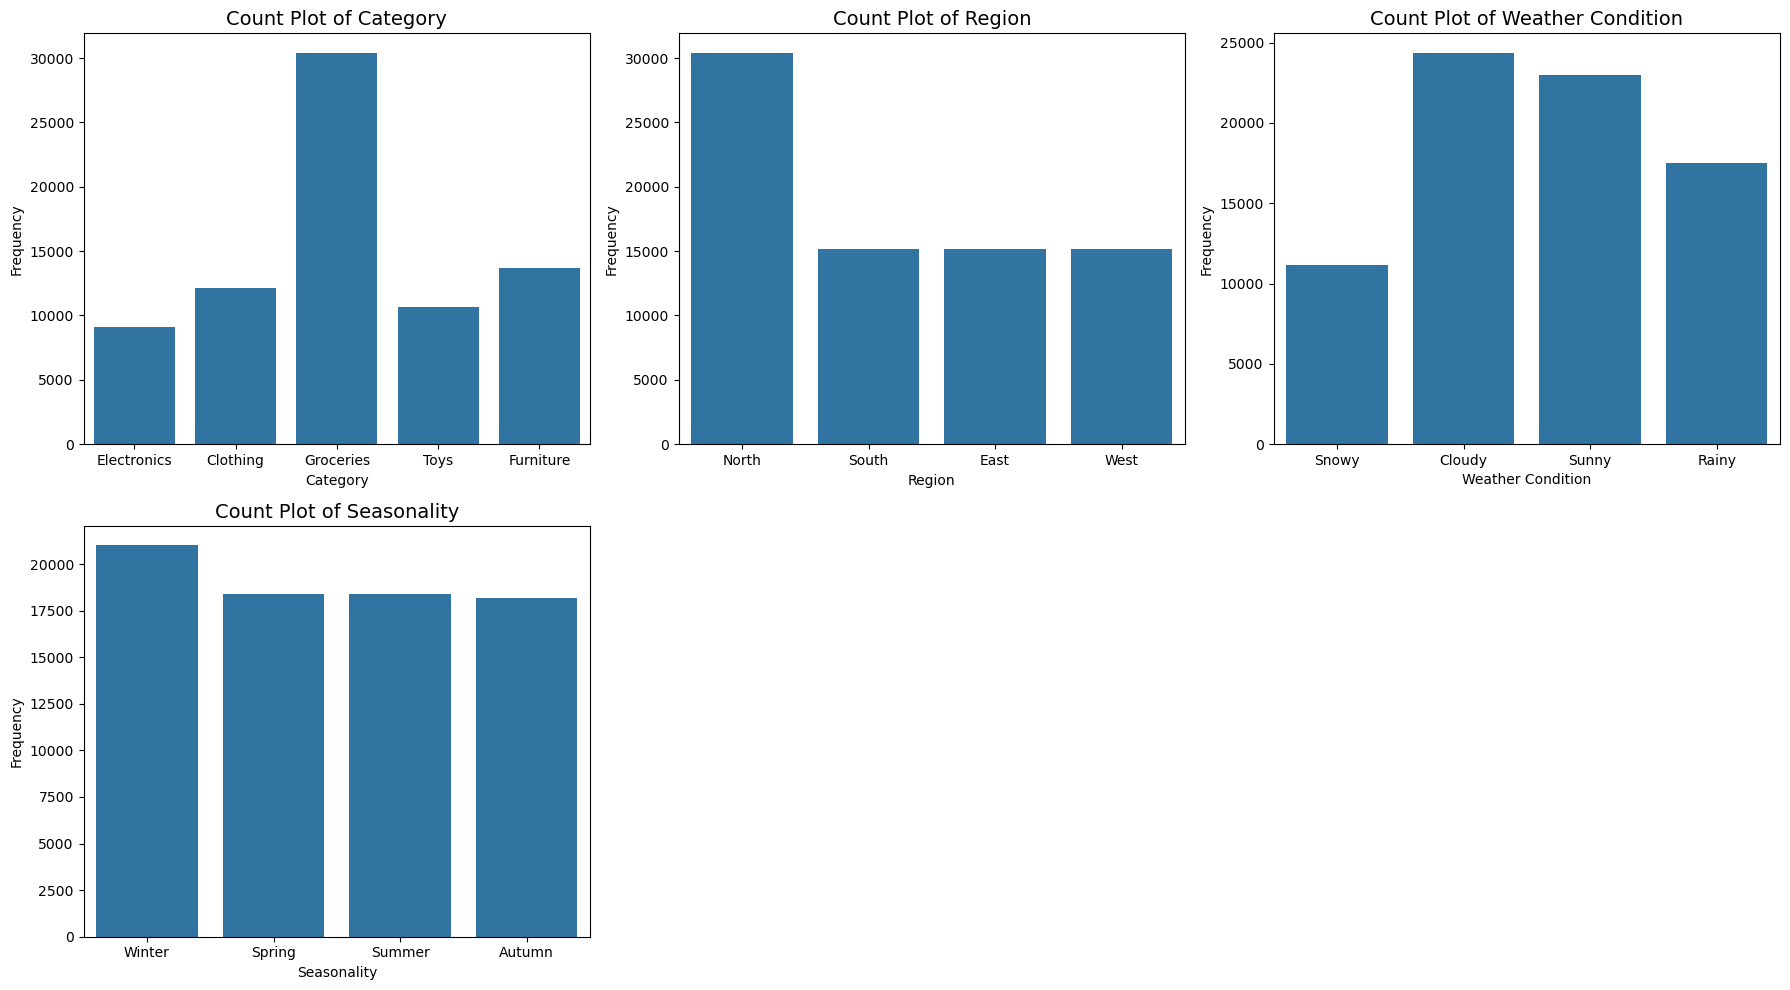

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, col in enumerate(categorical_columns[3:]):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f"Count Plot of {col}", fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide unused subplots
for i in range(len(categorical_columns[3:]), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### Insights

#### The categorical distributions show noticeable differences across several features. **Groceries** has the highest number of observations among categories, while **Electronics** and **Toys** have comparatively fewer observations. **North** has substantially more observations than the other regions. For weather conditions, **Cloudy** and **Sunny** are more frequent than **Snowy** and **Rainy**. **Winter** has slightly more observations than the other seasons, while Spring, Summer, and Autumn have relatively similar distributions.

# Target Variable Analysis — Demand

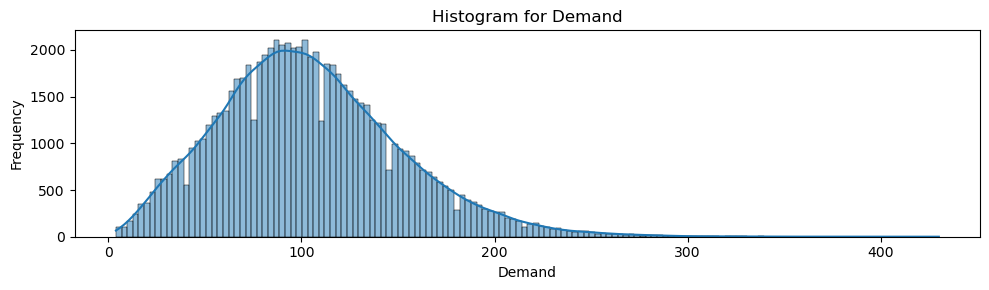

In [36]:
plt.figure(figsize=(10,3))

sns.histplot(
    data = df,
    x = "Demand",
    kde = True
)

plt.title("Histogram for Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.tight_layout()

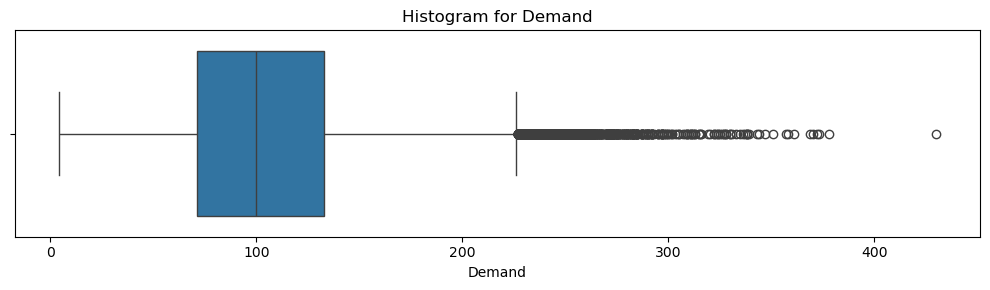

In [37]:
plt.figure(figsize=(10,3))

sns.boxplot(
    data = df,
    x = "Demand"
)

plt.title("Histogram for Demand")
plt.xlabel("Demand")
plt.tight_layout()

# Bivariate Analysis

### Categorical → Demand

In [38]:
categorical_columns

['Date',
 'Store ID',
 'Product ID',
 'Category',
 'Region',
 'Weather Condition',
 'Seasonality']

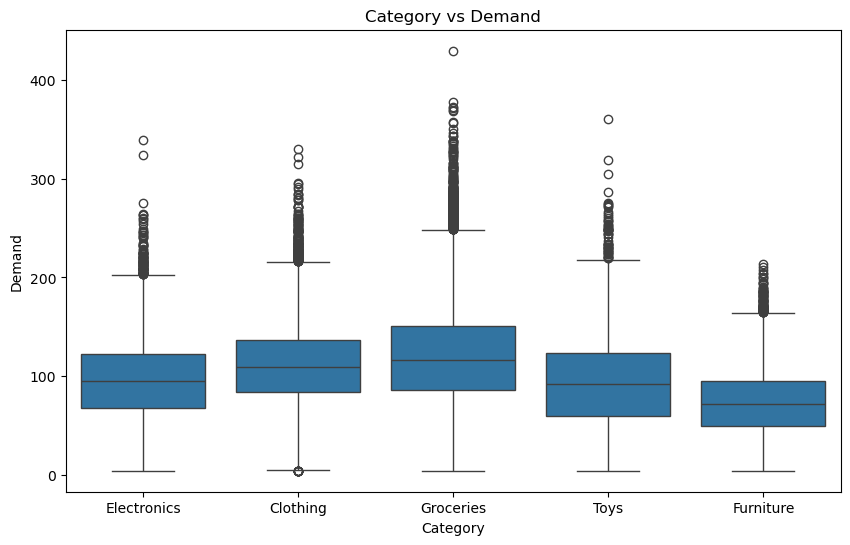

In [39]:
# Box plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Demand"
)

plt.title("Category vs Demand")
plt.xlabel("Category")
plt.ylabel("Demand")

plt.show()

### Insights

#### The boxplot shows that **demand varies across product categories**. **Groceries** has the highest median demand, followed by **Clothing**, while **Furniture** has the lowest median demand. Groceries also shows a relatively wider demand distribution with numerous high-demand observations. This indicates that **product category may be an important factor for predicting demand**.

In [40]:
df["Region"].unique()

array(['North', 'South', 'East', 'West'], dtype=object)

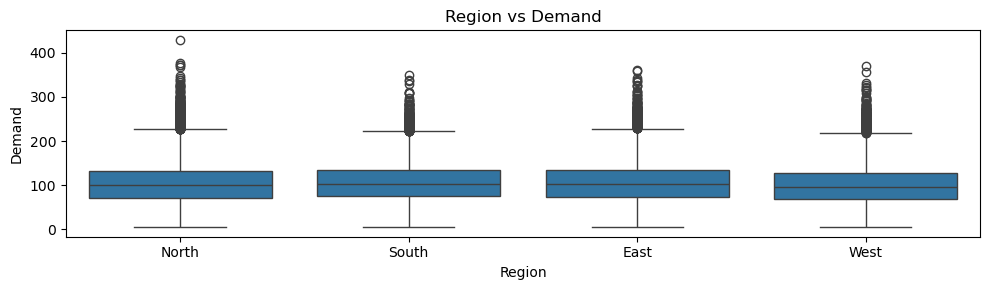

In [41]:
plt.figure(figsize=(10,3))

sns.boxplot(
    data = df,
    x = "Region",
    y = "Demand"
)

plt.title("Region vs Demand")
plt.xlabel("Region")
plt.ylabel("Demand")
plt.tight_layout()

### Insights

#### The boxplot shows that **demand distributions are broadly similar across all four regions**, with median demand values close to **100 units** and comparable spreads. Although all regions contain high-demand observations, there is no major difference in the central demand levels between regions. This suggests that **Region may have a relatively limited impact on demand compared with other features**, although its predictive value should be evaluated further during model development.

In [42]:
df["Weather Condition"].unique()

array(['Snowy', 'Cloudy', 'Sunny', 'Rainy'], dtype=object)

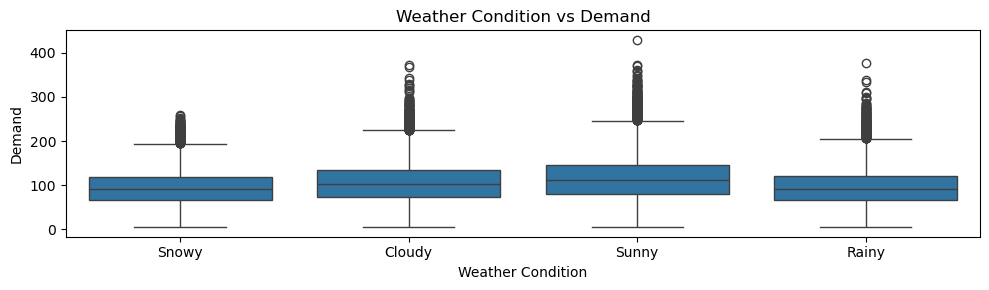

In [43]:
plt.figure(figsize=(10,3))

sns.boxplot(
    data = df,
    x = "Weather Condition",
    y = "Demand"
)

plt.title("Weather Condition vs Demand")
plt.xlabel("Weather Condition")
plt.ylabel("Demand")

plt.tight_layout()

### Insights

#### The boxplot shows that **demand varies across weather conditions**. **Sunny** conditions have the highest median demand, followed by **Cloudy**, while **Snowy** and **Rainy** conditions show comparatively lower median demand. Sunny conditions also have a relatively wider demand distribution with numerous high-demand observations. This suggests that **weather condition may be a useful feature for demand prediction**.

In [44]:
df["Seasonality"].unique()

array(['Winter', 'Spring', 'Summer', 'Autumn'], dtype=object)

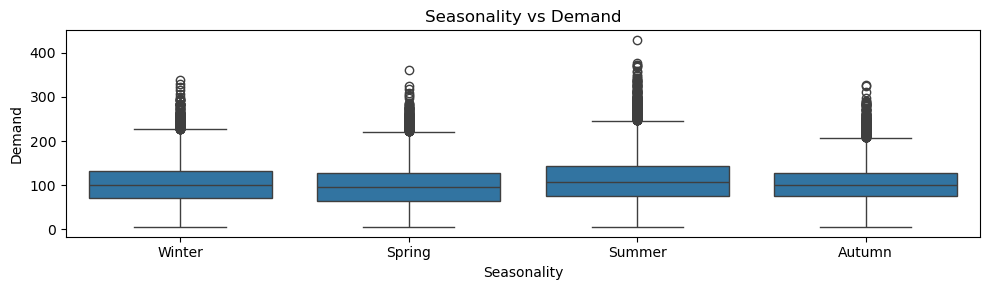

In [45]:
plt.figure(figsize=(10,3))

sns.boxplot(
    data = df,
    x = "Seasonality",
    y = "Demand"
)

plt.title("Seasonality vs Demand")
plt.xlabel("Seasonality")
plt.ylabel("Demand")

plt.tight_layout()

### Insights

#### The boxplot shows that **demand varies across seasons**. **Summer** has the highest median demand, while **Spring** has the lowest median demand. Winter and Autumn show relatively similar median demand levels. Summer also has a wider demand distribution and more extreme high-demand observations. This suggests that **seasonality may be an important factor for demand prediction**.

In [46]:
# Numerical Columns
numerical_columns

['Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Price',
 'Discount',
 'Promotion',
 'Competitor Pricing',
 'Epidemic',
 'Demand']

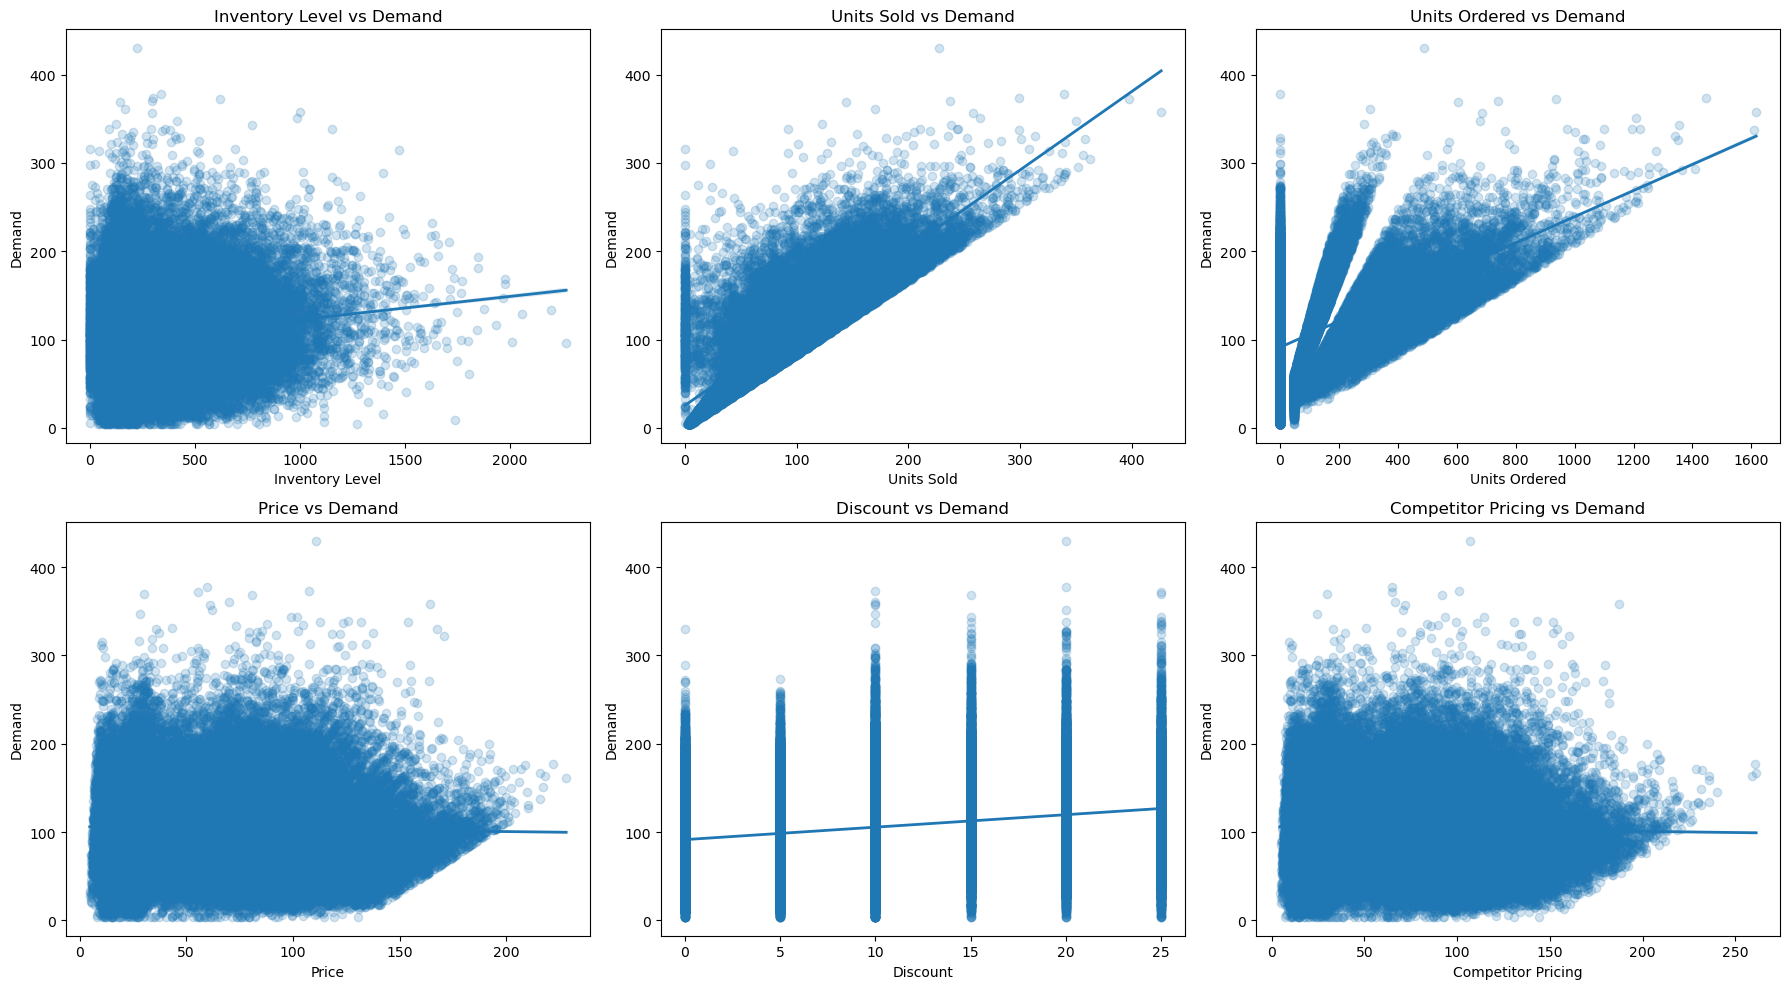

In [47]:
# Numerical variables to compare with Demand
features = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing"
]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

# Create scatter plot + trend line for each feature
for i, feature in enumerate(features):
    sns.regplot(
        data=df,
        x=feature,
        y="Demand",
        ax=axes[i],
        scatter_kws={"alpha": 0.2},
        line_kws={"linewidth": 2}
    )

    axes[i].set_title(f"{feature} vs Demand")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Demand")

plt.tight_layout()

### Insights

#### The scatter plots reveal different relationships between numerical features and demand. **Units Sold** shows the strongest positive relationship with demand, while **Units Ordered** also shows a noticeable positive relationship. **Inventory Level** shows a relatively weak positive relationship. **Price** and **Competitor Pricing** show weak and less consistent relationships with demand, while **Discount** shows a slight positive trend. Overall, the relationships suggest that demand is influenced by multiple factors rather than a single numerical feature.

# Correlation

In [48]:
# Correlation Matrix

corr_matrix = df[numerical_columns].corr()
corr_matrix

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
Inventory Level,1.000000,0.234590,-0.034698,-0.036673,-0.000678,-0.006082,-0.034754,-0.097550,0.126618
Units Sold,0.234590,1.000000,0.433943,-0.014506,0.183523,0.227062,-0.013989,-0.317855,0.833421
Units Ordered,-0.034698,0.433943,1.000000,0.044980,0.172972,0.214743,0.045235,-0.100546,0.511963
Price,-0.036673,-0.014506,0.044980,1.000000,-0.094136,-0.043190,0.976648,-0.089658,-0.023461
Discount,-0.000678,0.183523,0.172972,-0.094136,1.000000,0.784039,-0.092066,-0.003885,0.224723
Promotion,-0.006082,0.227062,0.214743,-0.043190,0.784039,1.000000,-0.041385,0.000700,0.282537
Competitor Pricing,-0.034754,-0.013989,0.045235,0.976648,-0.092066,-0.041385,1.000000,-0.089466,-0.023036
Epidemic,-0.097550,-0.317855,-0.100546,-0.089658,-0.003885,0.000700,-0.089466,1.000000,-0.363661
Demand,0.126618,0.833421,0.511963,-0.023461,0.224723,0.282537,-0.023036,-0.363661,1.000000


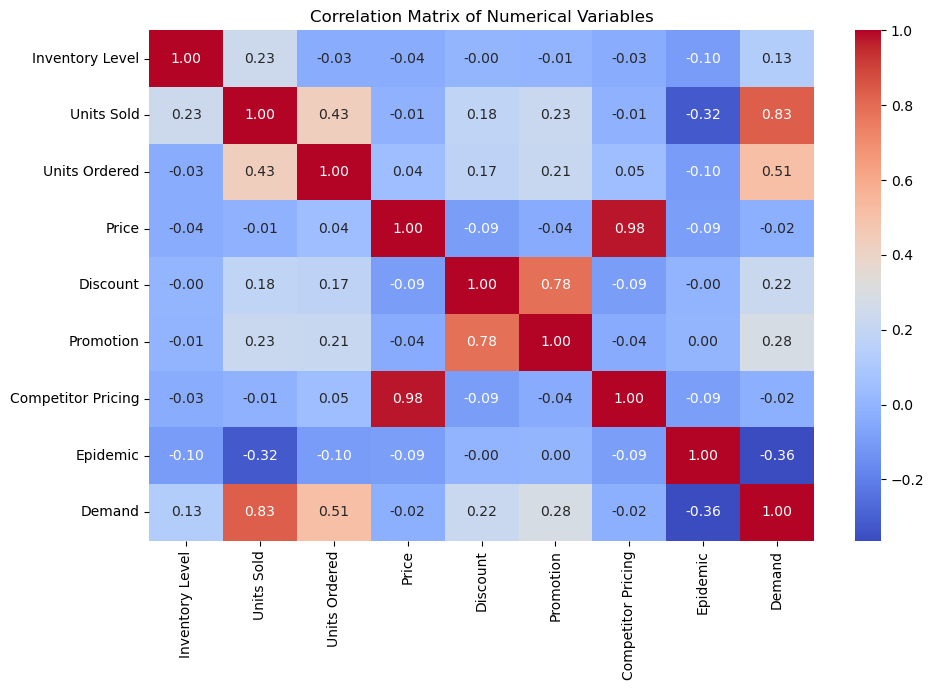

In [49]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Insights

#### The correlation matrix shows that **Units Sold** has the strongest positive correlation with Demand (**0.83**), followed by **Units Ordered** (**0.51**). **Epidemic** shows a moderate negative correlation with Demand (**-0.36**), while Promotion (**0.28**) and Discount (**0.22**) show weaker positive relationships. Inventory Level has a very weak positive correlation with Demand (**0.13**), whereas Price and Competitor Pricing show almost no linear correlation with Demand.

#### Among the independent variables, **Price and Competitor Pricing** have a very strong correlation (**0.98**), while **Discount and Promotion** also show a strong correlation (**0.78**). These relationships should be investigated further during feature engineering because they may introduce multicollinearity or redundant information.

# Pricing-Focused Analysis

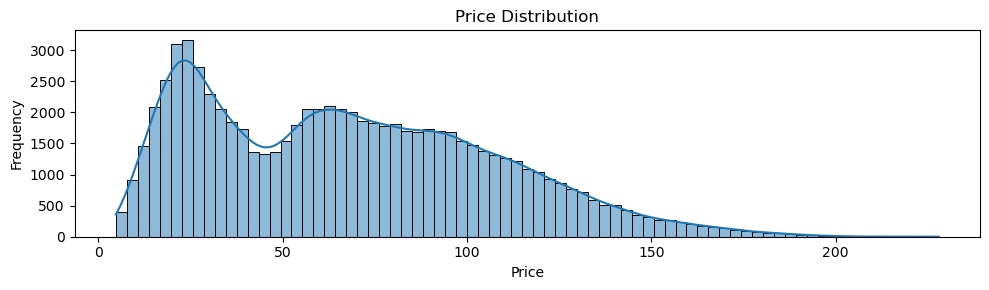

In [50]:
# Price Distribution

plt.figure(figsize=(10, 3))

sns.histplot(
    data=df,
    x="Price",
    kde = True
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Insights

#### The price distribution is **multi-modal and right-skewed**, with noticeable concentration around **25–30** and **60–70**. Most price values fall roughly between **20 and 120**, while a smaller number of observations extend beyond **150** and reach above **200**. This indicates that the dataset contains multiple price ranges and some relatively high-price observations that should be investigated further.

In [51]:
df["Price"].describe()

count    76000.000000
mean        67.726028
std         39.377899
min          4.740000
25%         31.997500
50%         64.500000
75%         95.830000
max        228.030000
Name: Price, dtype: float64

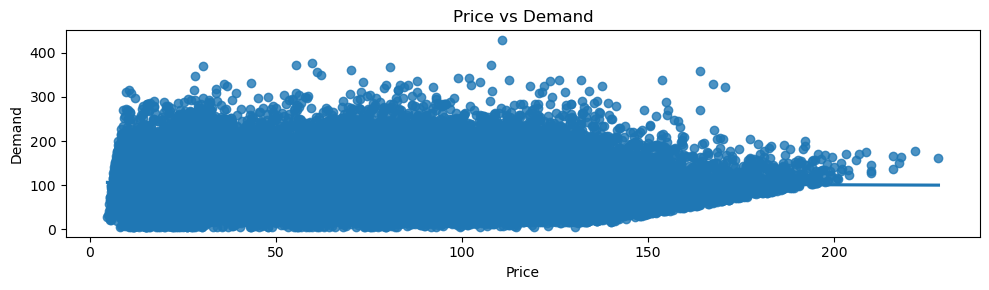

In [52]:
# Price vs Demand

plt.figure(figsize=(10,3))

sns.regplot(
    data = df,
    x = "Price",
    y = "Demand"
)

plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Demand")

plt.tight_layout()

### Insights

#### The scatter plot shows that **Price has a weak and non-linear relationship with Demand**. At lower and medium price levels, demand varies widely, while at higher price levels, demand becomes more concentrated within a narrower range. Overall, there is no clear strong linear pattern between price and demand, suggesting that **Price alone may not be sufficient to explain demand behavior**.

In [53]:
corr = df["Price"].corr(df["Demand"])

print("Correlation between Price and Demand:", corr)

Correlation between Price and Demand: -0.02346082195720527


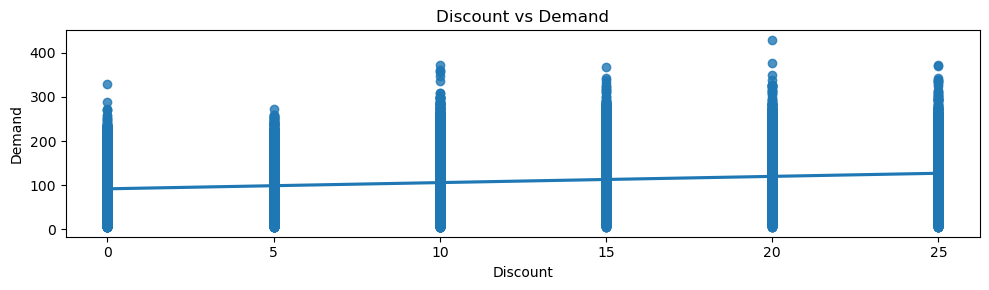

In [54]:
# Discount vs Demand

plt.figure(figsize=(10,3))

sns.regplot(
    data = df,
    x = "Discount",
    y = "Demand"
)

plt.title("Discount vs Demand")
plt.xlabel("Discount")
plt.ylabel("Demand")

plt.tight_layout()

### Insights

#### The scatter plot shows a **slight positive relationship between Discount and Demand**. Higher discount levels are generally associated with somewhat higher demand, but demand varies widely at each discount level. This indicates that **Discount may influence demand, but it is not sufficient by itself to explain demand variation**.

In [55]:
corr = df["Discount"].corr(df["Demand"])
print("Correlation between Discount and Demand:", corr)

Correlation between Discount and Demand: 0.2247226470291461


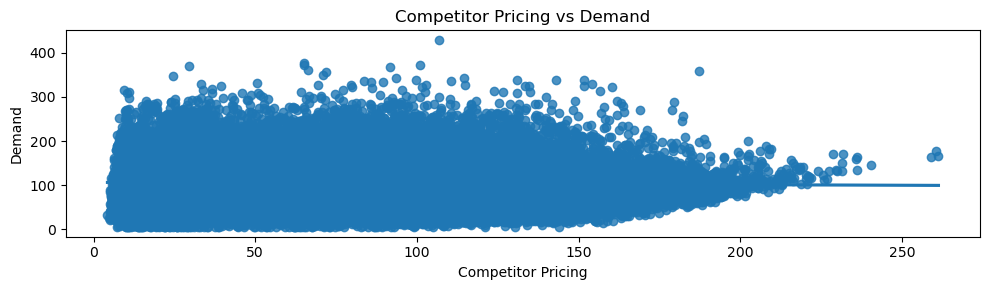

In [56]:
# Competitor Pricing vs Demand

plt.figure(figsize=(10,3))

sns.regplot(
    data = df,
    x = "Competitor Pricing",
    y = "Demand"
)

plt.title("Competitor Pricing vs Demand")
plt.xlabel("Competitor Pricing")
plt.ylabel("Demand")

plt.tight_layout()

### Insights

#### The scatter plot shows a **very weak relationship between Competitor Pricing and Demand**. Demand varies widely across lower and medium competitor price levels, while higher competitor prices show a more concentrated range of demand. The nearly flat trend line indicates that **Competitor Pricing alone has limited linear association with Demand**.

In [57]:
corr = df["Competitor Pricing"].corr(df["Demand"])
print("Correlation Competitor Pricing Price and Demand:", corr)

Correlation Competitor Pricing Price and Demand: -0.023036445032016562


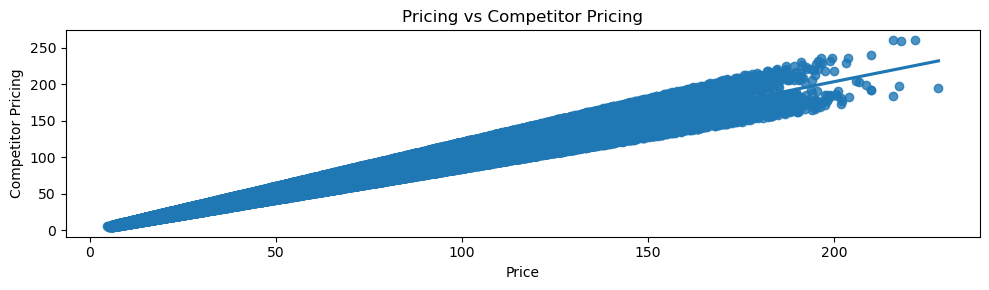

In [58]:
plt.figure(figsize=(10,3))

sns.regplot(
    data = df,
    x = "Price",
    y = "Competitor Pricing"
)

plt.title("Pricing vs Competitor Pricing")
plt.xlabel("Price")
plt.ylabel("Competitor Pricing")

plt.tight_layout()

### Insights

#### The scatter plot shows a **very strong positive relationship between Price and Competitor Pricing**. As the product price increases, competitor pricing also increases, with the observations closely following an upward trend. This confirms the high correlation (**0.98**) observed in the correlation matrix and indicates that these two features may contain highly redundant information.

In [59]:
corr = df["Competitor Pricing"].corr(df["Price"])
print("Correlation Competitor Pricing Price and Price:", corr)

Correlation Competitor Pricing Price and Price: 0.9766482862686701


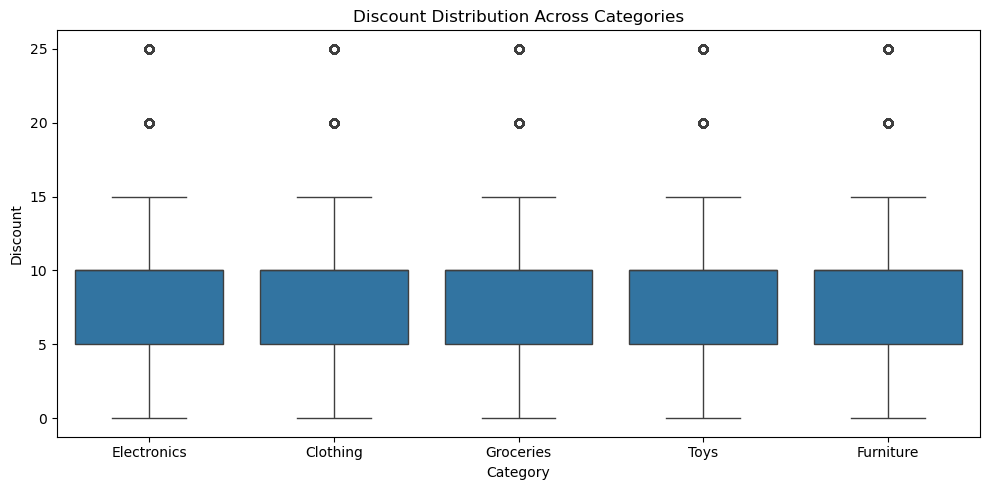

In [60]:
# •	Discount behavior across categories 

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Category",
    y="Discount"
)

plt.title("Discount Distribution Across Categories")
plt.xlabel("Category")
plt.ylabel("Discount")

plt.tight_layout()
plt.show()

### Insights

#### The discount distribution is **very similar across all product categories**, with the middle 50% of observations generally falling between **5% and 10%**. Discounts from **0% to 15%** form the typical range, while **20% and 25%** appear as higher-value observations across all categories. Since these are valid discount levels, they should not be treated as errors or removed automatically.

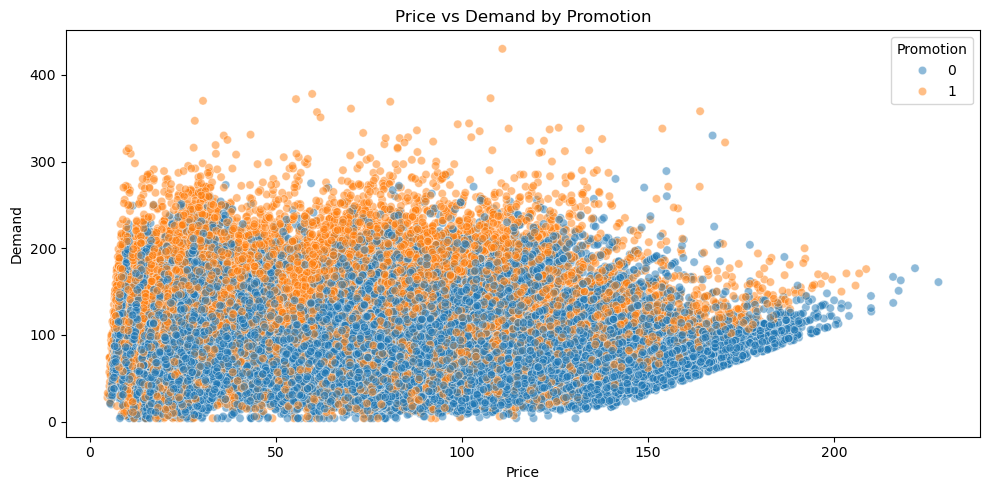

In [61]:
# Promotion + Price + Demand Relationships

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="Price",
    y="Demand",
    hue="Promotion",
    alpha=0.5
)

plt.title("Price vs Demand by Promotion")
plt.xlabel("Price")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

### Insights

#### The plot shows differences in demand between **promoted and non-promoted products** across price levels. Observations with **Promotion = 1** appear more frequently at higher demand levels, particularly across low-to-medium price ranges, compared with **Promotion = 0**. This suggests that **promotional activity may contribute to higher demand**, although the relationship is influenced by multiple other factors such as price and product characteristics.

# Time-Based Analysis

In [62]:
df["Date"] = pd.to_datetime(df["Date"])

In [63]:
df["Date"].dtype

dtype('<M8[ns]')

In [64]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Day_Name"] = df["Date"].dt.day_name()
df["Day_of_Week"] = df["Date"].dt.dayofweek

In [65]:
df["Day_Type"] = df["Day_of_Week"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [66]:
df.shape

(76000, 23)

In [67]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Seasonality,Epidemic,Demand,Year,Month,Month_Name,Day,Day_Name,Day_of_Week,Day_Type
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,Winter,0,115,2022,1,January,1,Saturday,5,Weekend
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,Winter,0,229,2022,1,January,1,Saturday,5,Weekend
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,Winter,0,157,2022,1,January,1,Saturday,5,Weekend
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,Winter,0,52,2022,1,January,1,Saturday,5,Weekend
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,Winter,0,59,2022,1,January,1,Saturday,5,Weekend


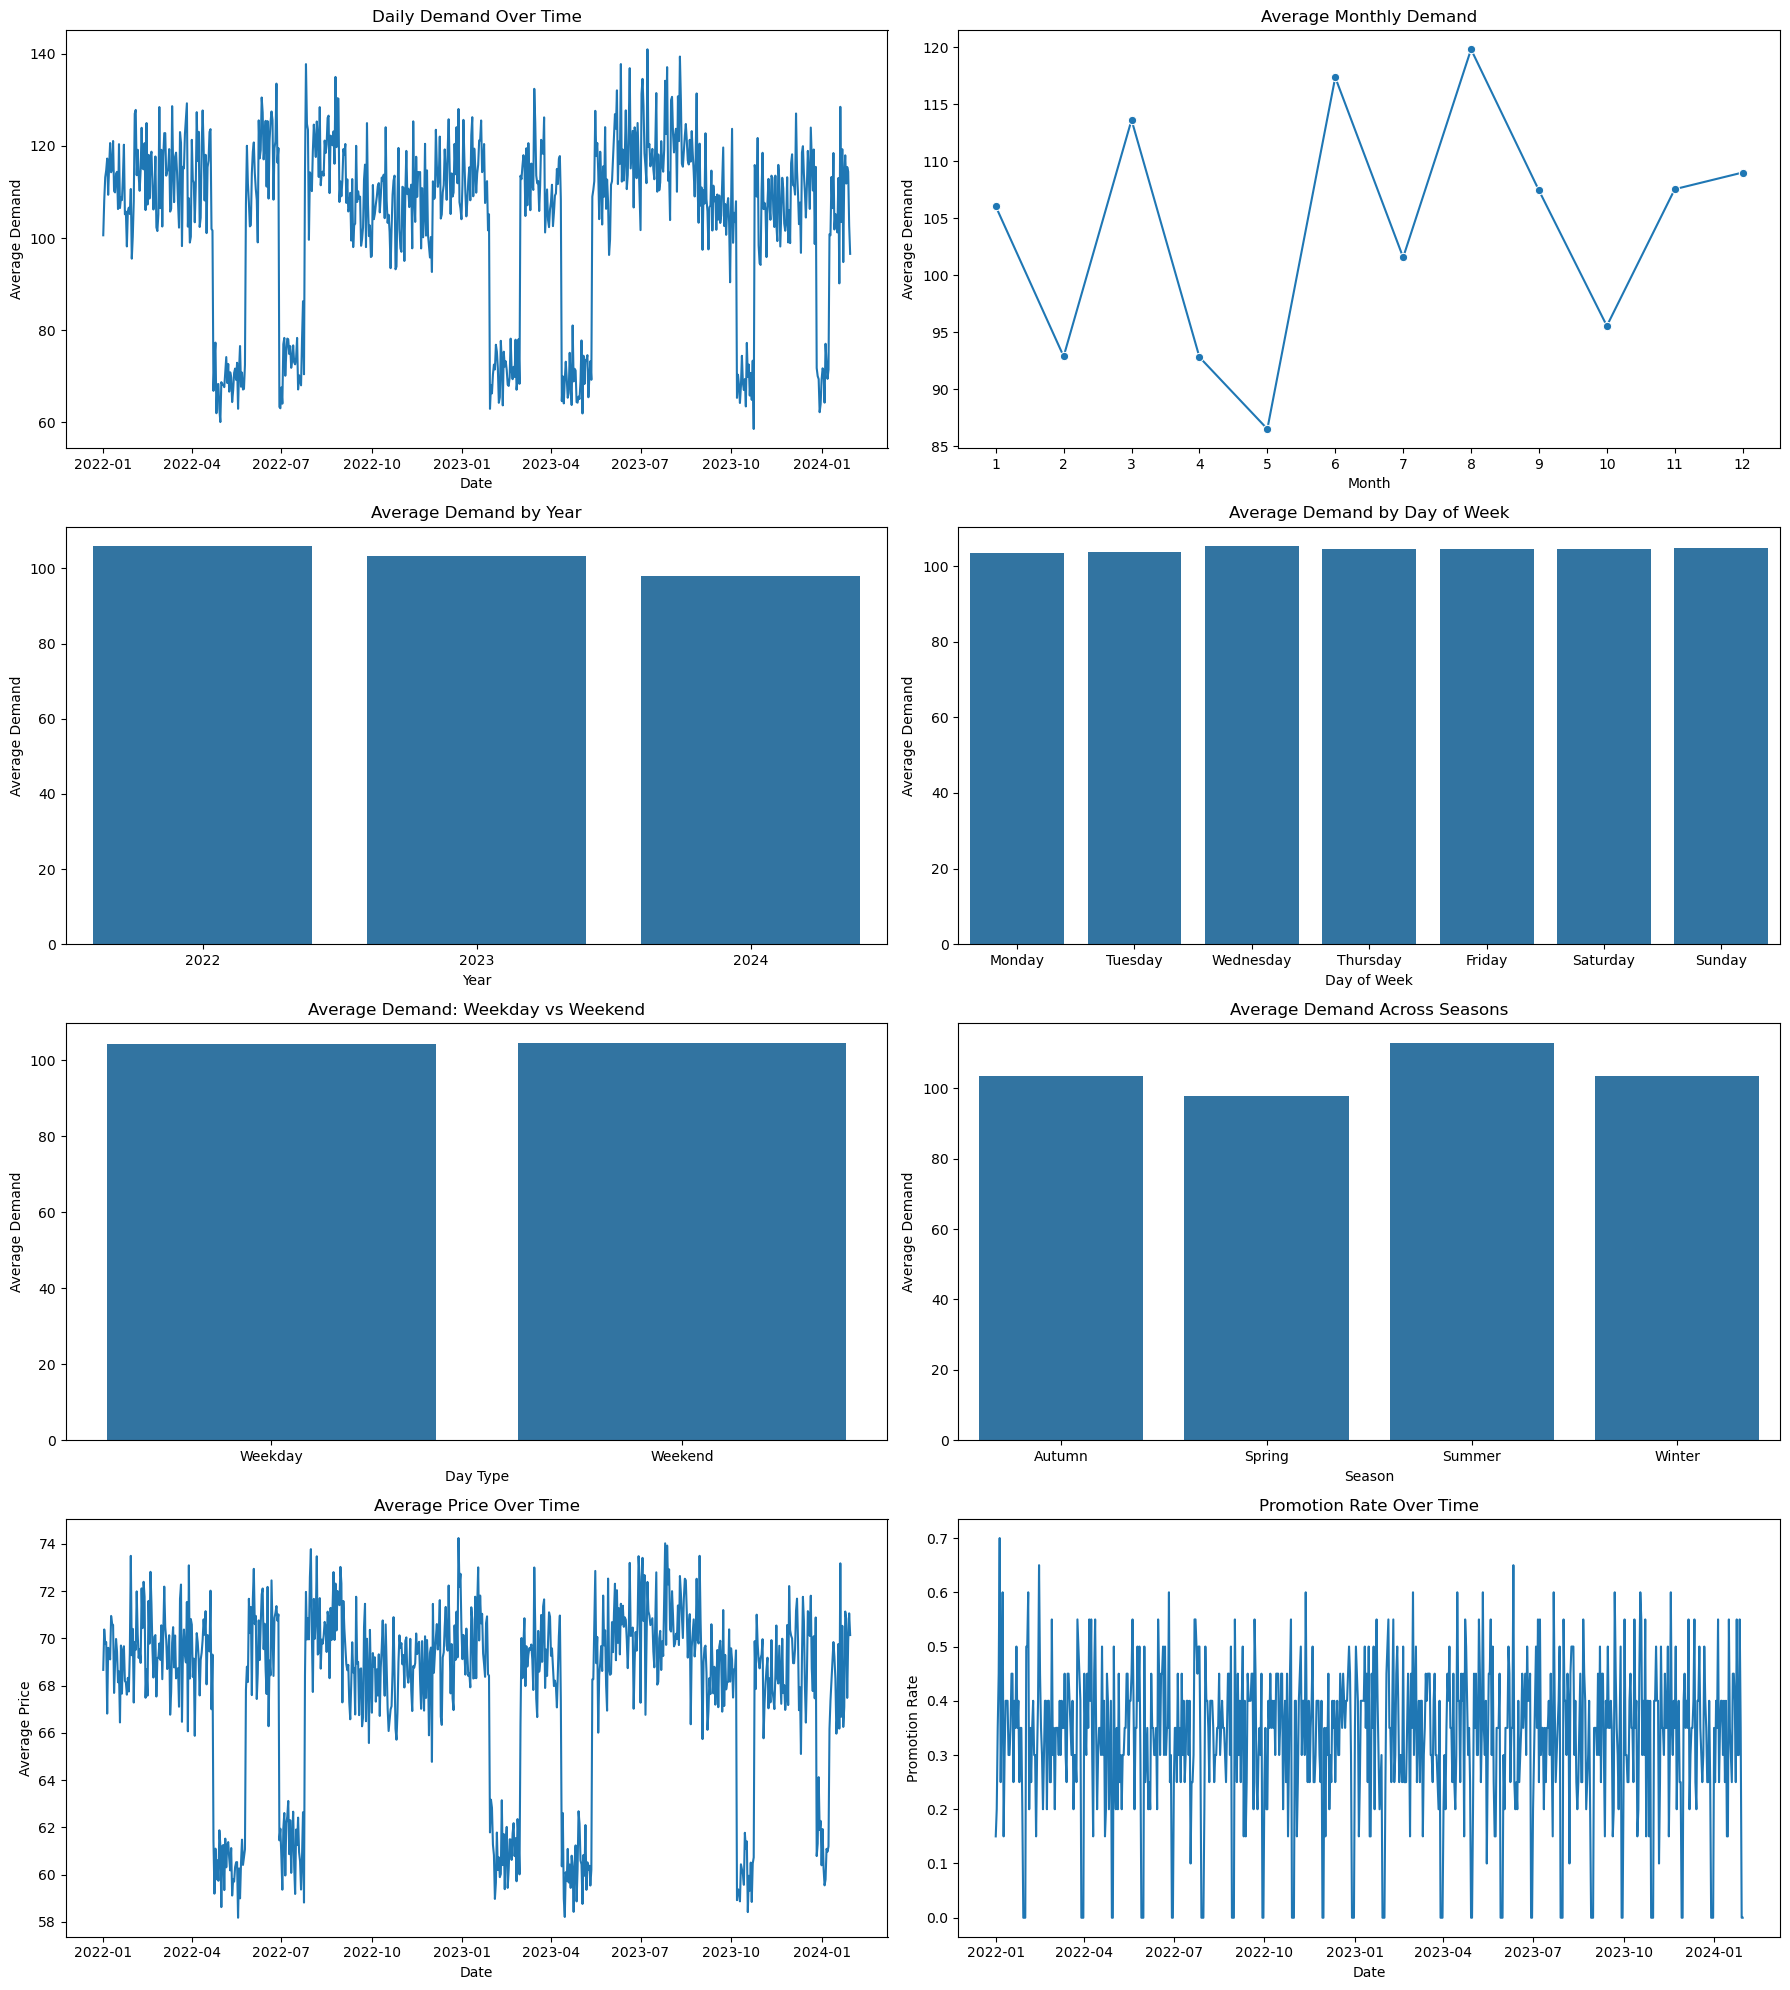

In [68]:
# =========================================================
# 2. AGGREGATE DATA
# =========================================================

daily_demand = df.groupby("Date")["Demand"].mean().reset_index()

monthly_demand = df.groupby("Month")["Demand"].mean().reset_index()

yearly_demand = df.groupby("Year")["Demand"].mean().reset_index()

day_demand = (
    df.groupby(["Day_of_Week", "Day_Name"])["Demand"]
    .mean()
    .reset_index()
    .sort_values("Day_of_Week")
)

weekday_weekend = (
    df.groupby("Day_Type")["Demand"]
    .mean()
    .reset_index()
)

seasonal_demand = (
    df.groupby("Seasonality")["Demand"]
    .mean()
    .reset_index()
)

daily_price = df.groupby("Date")["Price"].mean().reset_index()

promotion_daily = df.groupby("Date")["Promotion"].mean().reset_index()


# =========================================================
# 3. CREATE SUBPLOTS
# =========================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(18, 20)
)

axes = axes.flatten()


# =========================================================
# 4. PLOT 1 — DAILY DEMAND
# =========================================================

sns.lineplot(
    data=daily_demand,
    x="Date",
    y="Demand",
    ax=axes[0]
)

axes[0].set_title("Daily Demand Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Average Demand")


# =========================================================
# 5. PLOT 2 — MONTHLY DEMAND
# =========================================================

sns.lineplot(
    data=monthly_demand,
    x="Month",
    y="Demand",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Average Monthly Demand")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average Demand")
axes[1].set_xticks(range(1, 13))


# =========================================================
# 6. PLOT 3 — YEARLY DEMAND
# =========================================================

sns.barplot(
    data=yearly_demand,
    x="Year",
    y="Demand",
    ax=axes[2]
)

axes[2].set_title("Average Demand by Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Average Demand")


# =========================================================
# 7. PLOT 4 — DAY OF WEEK
# =========================================================

sns.barplot(
    data=day_demand,
    x="Day_Name",
    y="Demand",
    ax=axes[3]
)

axes[3].set_title("Average Demand by Day of Week")
axes[3].set_xlabel("Day of Week")
axes[3].set_ylabel("Average Demand")


# =========================================================
# 8. PLOT 5 — WEEKDAY VS WEEKEND
# =========================================================

sns.barplot(
    data=weekday_weekend,
    x="Day_Type",
    y="Demand",
    ax=axes[4]
)

axes[4].set_title("Average Demand: Weekday vs Weekend")
axes[4].set_xlabel("Day Type")
axes[4].set_ylabel("Average Demand")


# =========================================================
# 9. PLOT 6 — SEASONAL DEMAND
# =========================================================

sns.barplot(
    data=seasonal_demand,
    x="Seasonality",
    y="Demand",
    ax=axes[5]
)

axes[5].set_title("Average Demand Across Seasons")
axes[5].set_xlabel("Season")
axes[5].set_ylabel("Average Demand")


# =========================================================
# 10. PLOT 7 — PRICE OVER TIME
# =========================================================

sns.lineplot(
    data=daily_price,
    x="Date",
    y="Price",
    ax=axes[6]
)

axes[6].set_title("Average Price Over Time")
axes[6].set_xlabel("Date")
axes[6].set_ylabel("Average Price")


# =========================================================
# 11. PLOT 8 — PROMOTION OVER TIME
# =========================================================

sns.lineplot(
    data=promotion_daily,
    x="Date",
    y="Promotion",
    ax=axes[7]
)

axes[7].set_title("Promotion Rate Over Time")
axes[7].set_xlabel("Date")
axes[7].set_ylabel("Promotion Rate")

plt.tight_layout()
plt.savefig("E:/Personal_Projects/AI-Pricing-Intelligence-Platform/notebooks/time_based_analysis.png")

### Insights

#### The time-based analysis shows that **demand varies across dates, months, years, and seasons**. Monthly and seasonal patterns are more noticeable, with **August and Summer showing higher average demand**, while May and Spring show lower demand. Average demand also shows a slight decline from **2022 to 2024**. In contrast, demand differences between weekdays and weekends are minimal. These patterns indicate that **time-related features such as Month, Season, and Year may provide useful information for demand prediction**.

# Multivariate Analysis

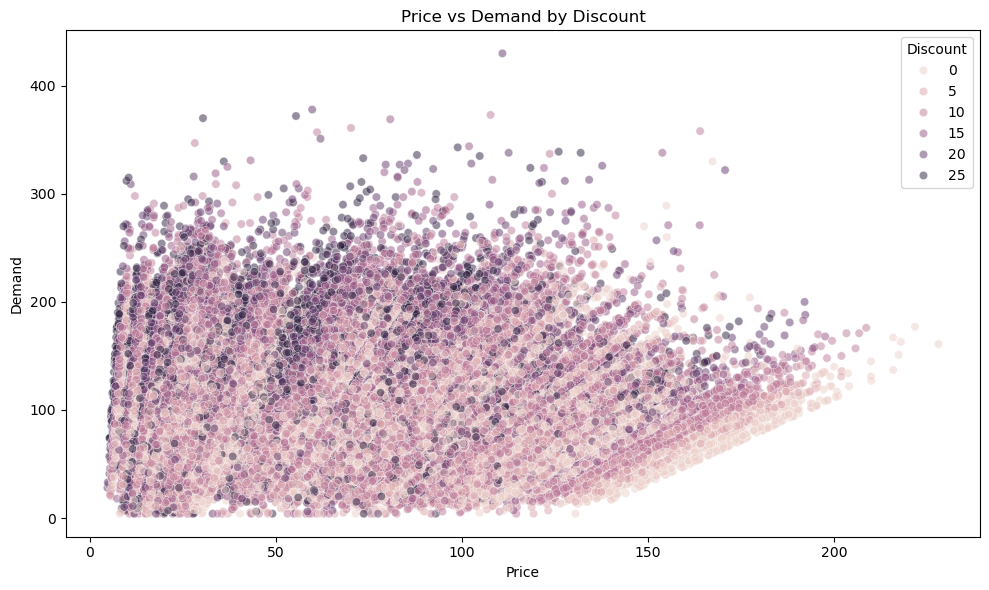

In [69]:
# Price + Discount + Demand

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Price",
    y="Demand",
    hue="Discount",
    alpha=0.5
)

plt.title("Price vs Demand by Discount")
plt.xlabel("Price")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

### Insights

#### The plot shows that **Demand varies considerably across different Discount levels and Price ranges**. Higher discount levels are more frequently associated with higher-demand observations, particularly at low-to-medium prices. However, substantial overlap exists between discount groups, indicating that **Discount does not independently determine Demand** and its effect should be considered together with Price and other relevant features.

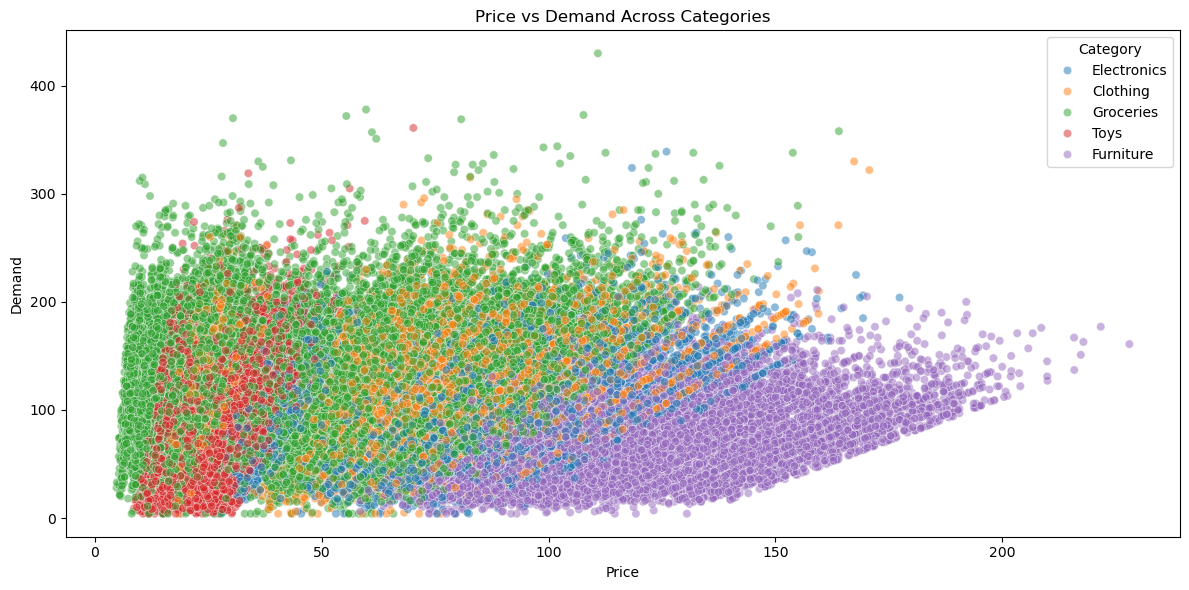

In [70]:
# Price + Category + Demand

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="Price",
    y="Demand",
    hue="Category",
    alpha=0.5
)

plt.title("Price vs Demand Across Categories")
plt.xlabel("Price")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

### Insights

#### The plot shows that the relationship between **Price and Demand differs across product categories**. **Groceries** cover a broad price range and contain many higher-demand observations, while **Furniture** is concentrated at higher price levels with comparatively lower demand. Electronics and Clothing occupy broader overlapping ranges, whereas Toys are more concentrated toward lower prices. This indicates that **Category may influence how Price relates to Demand** and could provide useful information for demand prediction.

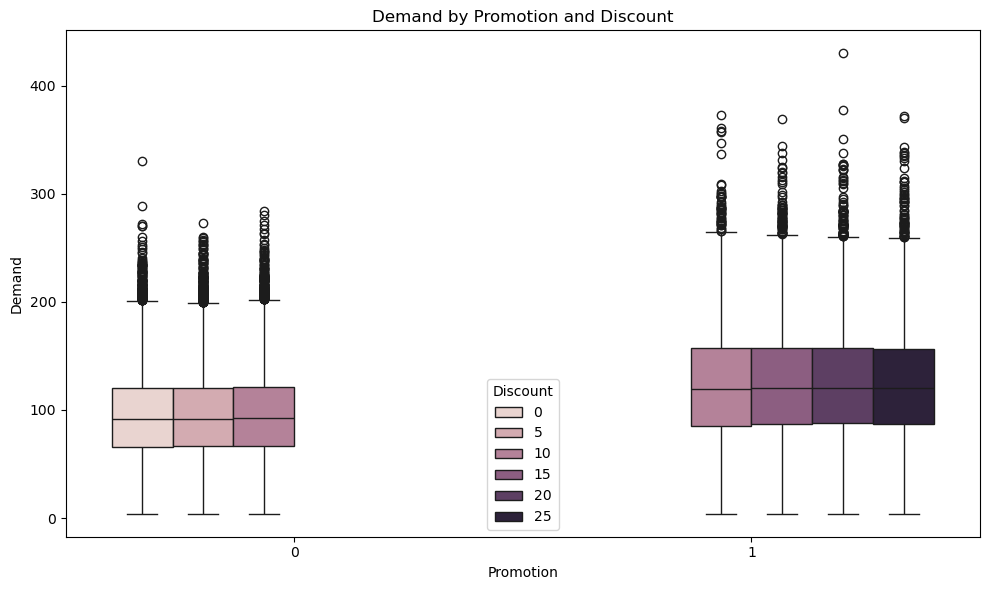

In [72]:
# Promotion + Discount + Demand

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Promotion",
    y="Demand",
    hue="Discount"
)

plt.title("Demand by Promotion and Discount")
plt.xlabel("Promotion")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

### Insights

#### The boxplot shows a clear difference in demand between **promoted and non-promoted observations**. The median demand is approximately **90 units without promotion** and around **120 units with promotion**, indicating that promoted products generally experience higher demand. However, demand differences across the individual discount levels within each promotion group appear relatively small. This suggests that **Promotion may have a stronger association with Demand than Discount alone**, although both factors should be considered together during model development.

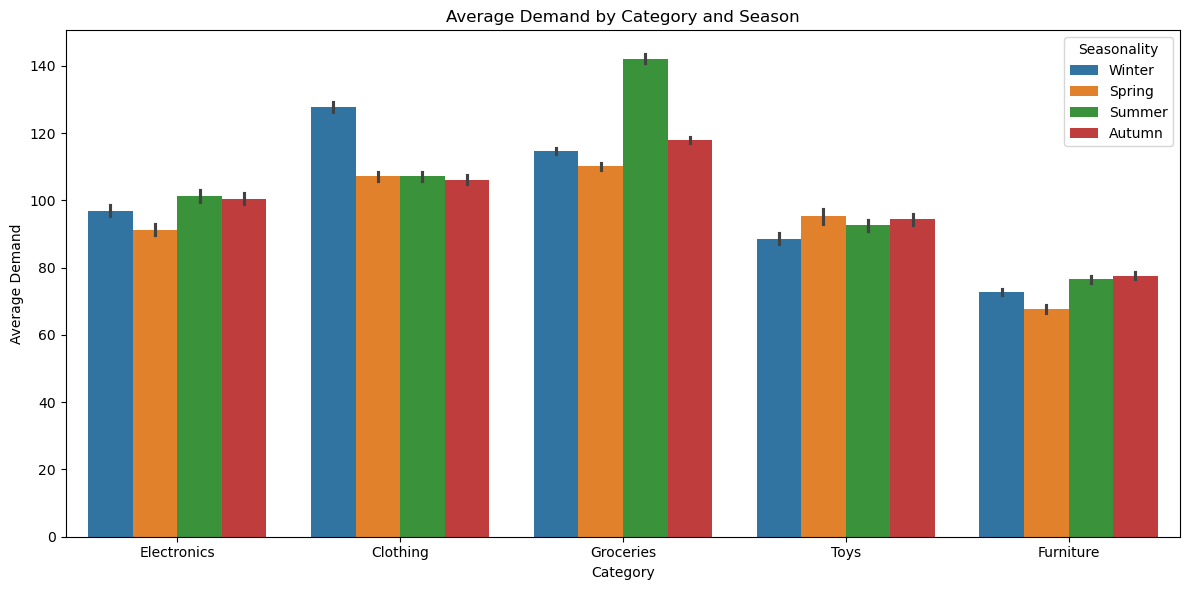

In [73]:
# Category + Seasonality + Demand

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Category",
    y="Demand",
    hue="Seasonality"
)

plt.title("Average Demand by Category and Season")
plt.xlabel("Category")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

### Insights

#### The analysis shows that **seasonal demand patterns differ across product categories**. **Groceries** show the strongest seasonal variation, with demand reaching its highest level during **Summer**, while **Clothing** has notably higher demand during **Winter**. Electronics and Toys show relatively smaller seasonal differences, whereas Furniture has the lowest overall demand across seasons. This indicates that **the interaction between Category and Seasonality may provide valuable information for demand prediction**.

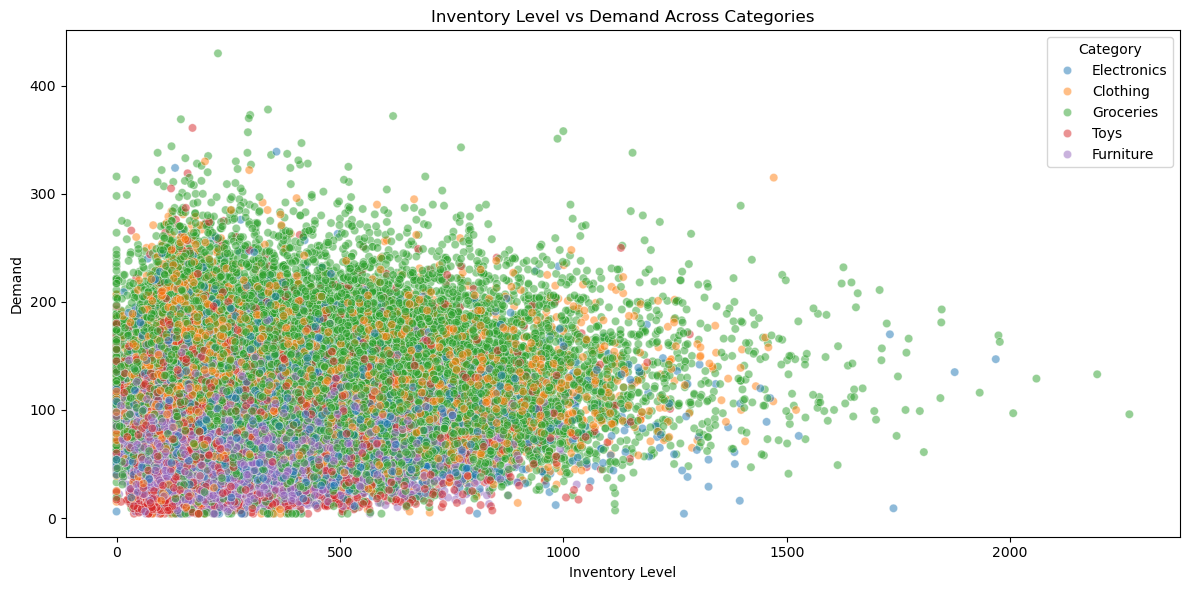

In [74]:
# Inventory + Demand + Category

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="Inventory Level",
    y="Demand",
    hue="Category",
    alpha=0.5
)

plt.title("Inventory Level vs Demand Across Categories")
plt.xlabel("Inventory Level")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

### Insights

#### The plot shows that the relationship between **Inventory Level and Demand varies across product categories**. **Groceries** cover the widest inventory range and contain many higher-demand observations, while **Furniture** is more concentrated toward lower demand levels. Electronics and Clothing show broader demand variation, whereas Toys generally remain at lower-to-moderate demand levels. Overall, the substantial scatter indicates that **Inventory Level alone does not determine Demand**, and its relationship with demand may depend on the product category.

In [75]:
# Competitor Pricing + Price + Demand

df["Price_Difference"] = (
    df["Price"] - df["Competitor Pricing"]
)

In [76]:
df["Competitive_Price_Position"] = pd.cut(
    df["Price_Difference"],
    bins=[-float("inf"), 0, float("inf")],
    labels=["Cheaper than Competitor", "More Expensive than Competitor"]
)

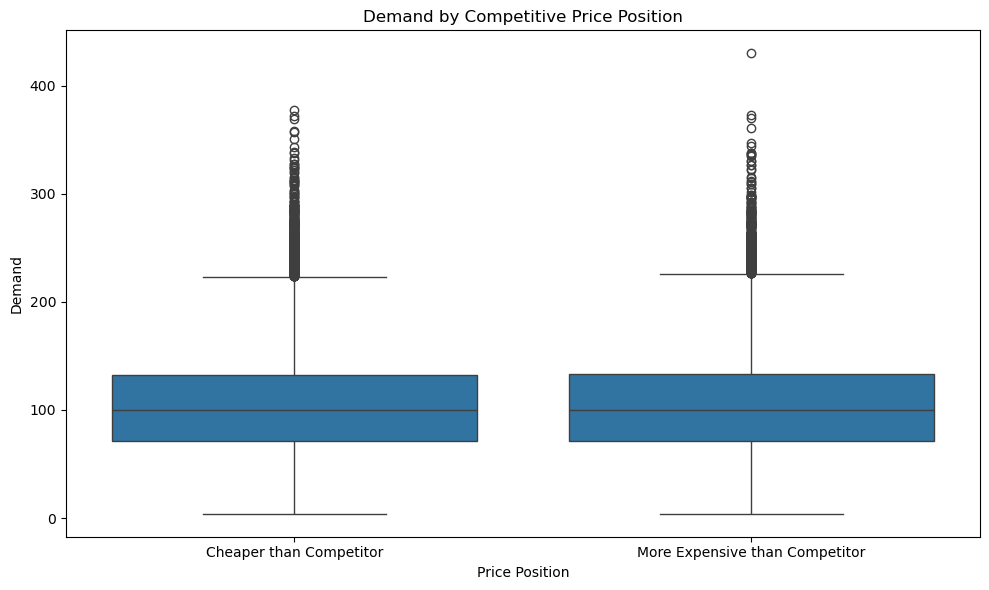

In [77]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Competitive_Price_Position",
    y="Demand"
)

plt.title("Demand by Competitive Price Position")
plt.xlabel("Price Position")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

### Insights

#### The boxplot shows that **Demand is very similar whether the product is cheaper or more expensive than the competitor**. Both groups have a median demand of approximately **100 units** and comparable distributions. This suggests that **competitive price position alone may have a limited impact on Demand**, although its predictive value should be evaluated together with other features.

# Business Insights

The exploratory data analysis provides several important insights into the factors associated with Demand and the overall pricing behavior of the dataset.

### 1. Demand Distribution
- Demand is generally concentrated around moderate levels, with most observations falling approximately between **70 and 130 units**.
- The distribution is right-skewed, with several high-demand observations reaching up to approximately **430 units**.
- These high-demand observations should be investigated further because they may represent genuine business situations rather than data errors.

### 2. Category and Demand
- Demand varies across product categories.
- **Groceries** show the highest median demand, followed by **Clothing**, while **Furniture** has the lowest median demand.
- This indicates that **Category is an important demand-related variable** and may be useful for demand prediction.

### 3. Weather and Seasonality
- Demand differs across weather conditions, with **Sunny** conditions showing the highest median demand and **Rainy/Snowy** conditions showing comparatively lower demand.
- Seasonal differences are also visible, with **Summer showing the highest median demand** and **Spring showing the lowest**.
- Therefore, **Weather and Seasonality may provide useful demand signals**.

### 4. Numerical Demand Drivers
- **Units Sold** has the strongest positive correlation with Demand (**0.83**).
- **Units Ordered** also shows a noticeable positive relationship with Demand (**0.51**).
- **Inventory Level** has only a weak positive relationship with Demand (**0.13**).
- **Discount** has a weak positive relationship with Demand (**0.22**).
- **Price** and **Competitor Pricing** have almost no linear correlation with Demand individually.

### 5. Pricing Relationships
- Price has a weak and non-linear relationship with Demand, indicating that **Price alone does not sufficiently explain Demand variation**.
- Higher discount levels appear to be associated with somewhat higher Demand, although substantial variation remains within each discount level.
- **Price and Competitor Pricing have a very strong positive correlation (0.98)**, indicating that the two variables contain highly similar pricing information.

### 6. Promotion and Demand
- Promoted observations generally show higher Demand than non-promoted observations.
- The median Demand is approximately **90 units without promotion** and **120 units with promotion**.
- This suggests that **Promotion may have a stronger association with Demand than Discount alone**, although other factors may also contribute to the observed difference.

### 7. Competitive Pricing Position
- Demand distributions are broadly similar when products are cheaper or more expensive than their competitors.
- Both groups have a median Demand of approximately **100 units**.
- Therefore, competitive price position alone does not appear to be a strong differentiator of Demand in this dataset.

### 8. Time-Based Patterns
- Demand varies across dates, months, years, and seasons.
- **August and Summer** show relatively higher average Demand, while **May and Spring** show lower average Demand.
- Average Demand shows a slight decline from **2022 to 2024**.
- Weekday and weekend Demand are relatively similar.
- These observations indicate that **Month, Year, Seasonality, and other time-related features may provide useful information for demand prediction**.

### 9. Category-Specific Patterns
- The relationship between Price and Demand differs across categories.
- Groceries cover a broad price range and contain many higher-demand observations, while Furniture is concentrated at higher prices with comparatively lower Demand.
- Seasonal behavior also differs by category. **Groceries show stronger seasonal variation, particularly during Summer, while Clothing shows higher Demand during Winter.**
- This suggests that **interactions between Category, Price, and Seasonality may be valuable for ML models**.

### 10. Overall Business Insight
Overall, Demand appears to be influenced by a combination of **sales activity, product category, promotion, discount, seasonality, weather, and operational factors** rather than by a single variable. The EDA also shows that some variables are highly related to each other, particularly **Price and Competitor Pricing**, which should be considered during feature engineering and model development.

# EDA Conclusion

The exploratory data analysis provides a clear understanding of the major patterns and relationships present in the dataset and identifies several variables that can be considered during the next stages of the project.

### 1. Most Important Demand Drivers

The strongest observed relationships with Demand are:

- **Units Sold** — strongest positive correlation with Demand (**0.83**).
- **Units Ordered** — moderate positive correlation with Demand (**0.51**).
- **Promotion** — promoted observations show noticeably higher median Demand.
- **Category** — Demand differs substantially across product categories.
- **Seasonality** — Demand varies across seasons, with Summer showing higher demand.
- **Weather** — Demand varies across different weather conditions.
- **Time-related features** — monthly, yearly, and seasonal variations are present.

These variables should receive particular attention during model development.

### 2. Important Pricing Relationships

- **Price vs Demand** shows a weak and non-linear relationship, indicating that Price alone is not sufficient to explain Demand.
- **Discount vs Demand** shows a weak positive association, with higher discounts generally associated with somewhat higher Demand.
- **Competitor Pricing vs Demand** shows a very weak linear relationship.
- **Price and Competitor Pricing** are extremely strongly correlated (**0.98**), indicating substantial redundancy between the two variables.
- Promotional observations generally show higher Demand than non-promotional observations.
- Competitive price position alone shows limited differences in Demand between products that are cheaper or more expensive than competitors.

Therefore, pricing variables should be considered jointly with **Promotion, Discount, Category, Seasonality, and other demand-related variables**.

### 3. Important Time and Seasonal Patterns

The analysis identifies several temporal patterns:

- Demand varies considerably across dates and months.
- **August** shows relatively high average Demand.
- **Summer** shows higher seasonal Demand, while **Spring** shows lower Demand.
- Average Demand shows a slight decline from **2022 to 2024**.
- Weekday and weekend Demand differences are relatively small.
- Time-related variables such as **Month, Year, Day of Week, and Seasonality** may therefore provide useful predictive information.

### 4. Important Operational Patterns

Operational variables also show useful patterns:

- Inventory Level is positively associated with Demand, but the relationship is weak.
- Inventory Level contains substantial variability and high-value observations.
- Units Sold and Units Ordered show stronger relationships with Demand than Inventory Level.
- The Inventory-Demand relationship varies across product categories.
- High inventory does not necessarily correspond to high Demand, indicating that inventory should not be interpreted as a direct measure of customer demand.

### 5. Variables That Appear Useful for Machine Learning

Based on the EDA, the following variables appear potentially useful for Demand prediction:

- **Category**
- **Region**
- **Weather**
- **Seasonality**
- **Promotion**
- **Discount**
- **Inventory Level**
- **Units Sold**
- **Units Ordered**
- **Month**
- **Year**
- **Day of Week**
- **Price**
- **Competitor Pricing**

However, usefulness for ML should ultimately be confirmed using proper model evaluation and feature-importance techniques rather than correlation alone.

### 6. Variables Requiring Further Investigation

Several relationships require additional investigation:

- The relationship between **Price and Demand** is weak and non-linear.
- The effect of **Discount** appears positive but relatively weak.
- **Competitor Pricing** has limited direct linear association with Demand.
- **Inventory Level** shows substantial variation and potential high-value observations.
- Demand contains high-value observations that may represent genuine business events or special conditions.
- The interaction between **Category, Seasonality, Promotion, Discount, and Price** may explain patterns that are not visible from individual variables.

These relationships should be investigated further during feature engineering and model development.

### 7. Potential Leakage Concerns

Some variables require careful consideration before training a Demand prediction model.

**Units Sold** and **Units Ordered** show strong relationships with Demand. If these variables represent information that becomes available only after or at the same time as the Demand being predicted, using them as input features could introduce **target leakage**.

Therefore, their availability at prediction time must be verified before including them in the final ML feature set.

Similarly, any feature derived using future information, future demand, or aggregated information from the complete dataset must be constructed carefully to avoid using information that would not have been available at prediction time.

### 8. Multicollinearity and Redundant Features

The correlation analysis identified very strong relationships among some independent variables:

- **Price ↔ Competitor Pricing = 0.98**
- **Discount ↔ Promotion = 0.78**

These relationships indicate potential redundancy or multicollinearity.

During feature engineering and model development, these variables should be evaluated carefully. Depending on the selected ML algorithm, it may be appropriate to retain, transform, or remove highly redundant features.

### 9. What Should Be Carried Forward into Feature Engineering?

The EDA suggests several useful feature-engineering directions:

- Extract **Year, Month, Day of Week, and Day Type** from Date.
- Retain **Seasonality** and **Weather** as categorical demand signals.
- Encode **Category, Region, and other categorical variables** appropriately.
- Consider **Price Difference from Competitor** as a pricing-position feature.
- Consider **Price Level** and **Discount Level** for grouped pricing analysis.
- Investigate **Price + Discount + Promotion** interactions.
- Investigate **Category + Seasonality** interactions.
- Investigate **Category + Price** interactions.
- Evaluate whether **Units Sold and Units Ordered** are available at prediction time before using them as features.
- Investigate highly correlated features such as **Price and Competitor Pricing** to avoid unnecessary redundancy.

### Final Conclusion

Overall, the EDA indicates that Demand is influenced by a combination of **sales activity, product characteristics, pricing and promotional conditions, seasonality, weather, and operational factors**. No single variable completely explains Demand. The strongest observed numerical relationships involve Units Sold and Units Ordered, while Category, Promotion, Seasonality, and Weather provide important categorical and contextual information.

The next stage should therefore focus on **careful feature engineering, leakage prevention, handling of skewed variables and outliers, treatment of categorical variables, and evaluation of feature interactions** before developing the final Demand prediction model.